# Paralog Dependency Analysis

Comparison of **significant** vs **non-significant** paralog pairs across five molecular properties:

| Analysis | Dataset |
|---|---|
| RNA half-life | Tani et al. 2012 (*Genome Research*, human) |
| Protein half-life | Mathieson et al. 2018 (*Cell Systems*, human; B cells, NK cells, hepatocytes, monocytes) |
| Protein localisation | Human Protein Atlas v25 (subcellular_location.tsv) |
| Mono-allelic expression | MaGIC / Nag et al. 2013 (*eLife*) – chromatin-based classifier, applied to 10 ENCODE cell lines with copy-number stratification |
| Copy number | DepMap 24Q4 – WGS absolute CN (GM12878, MCF-7, A549, HeLa-S3, Panc1, PC-3) and segment-calibrated CN (K562, HepG2, HCT116, SK-N-SH) |

**Gene groups:**
- **Significant (sig):** 37 paralog pairs (`dep_gene`, `paralog_gene`) from `sig_37_paralog copy.xlsx`
- **Non-significant (non-sig):** 28,103 paralog pairs (`hgnc_symbol`, `para_gene_2`) from `non_sig_paralog copy.xlsx` (deduplicated)

**Pair-level approach:** For each pair, both genes' properties are retrieved; pair-level metrics (e.g., within-pair half-life difference, location Jaccard similarity) are computed and compared between groups.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import zipfile
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
SIG_COLOR   = '#E74C3C'   # red  – significant pairs
NSIG_COLOR  = '#3498DB'   # blue – non-significant pairs

DATA_DIR = 'data/'
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1 · Load Paralog Lists

In [2]:
# ── Significant pairs ────────────────────────────────────────────────────────
sig = pd.read_excel('sig_37_paralog copy.xlsx')
sig_pairs = sig[['dep_gene', 'paralog_gene']].copy()
sig_pairs.columns = ['gene_A', 'gene_B']
sig_pairs['group'] = 'Significant'

# ── Non-significant pairs ────────────────────────────────────────────────────
non_sig = pd.read_excel('non_sig_paralog copy.xlsx')
# Each row: hgnc_symbol ↔ para_gene_2 (para_gene_1 == hgnc_symbol always)
ns_pairs = non_sig[['hgnc_symbol', 'para_gene_2']].drop_duplicates().copy()
ns_pairs.columns = ['gene_A', 'gene_B']
ns_pairs['group'] = 'Non-significant'

# ── Combined ─────────────────────────────────────────────────────────────────
all_pairs = pd.concat([sig_pairs, ns_pairs], ignore_index=True)

print(f'Significant pairs:     {len(sig_pairs):>6,}')
print(f'Non-significant pairs: {len(ns_pairs):>6,}')
print(f'Total pairs:           {len(all_pairs):>6,}')

Significant pairs:         37
Non-significant pairs: 28,103
Total pairs:           28,140


## 2 · RNA Half-Life & Protein Half-Life Data

**RNA half-life:** Tani et al. (2012) *Genome Research* 22, 947–956.  
Human mRNA half-lives measured by metabolic labelling (~11,000 genes). Column: `mrna_hl_h`.

**Protein half-life:** Mathieson et al. (2018) *Cell Systems* 7, 619–631.  
Human protein half-lives measured by dynamic SILAC in four primary cell types (B cells, NK cells, hepatocytes, monocytes), two replicates each. Half-lives are averaged across all 8 human replicates per gene (nanmean, excluding NaN).


In [3]:
# Load Tani 2012 (human mRNA half-life)
tani = pd.read_csv(DATA_DIR + 'Tani_2012_mRNA_HL_human.csv')
gene_to_rhl: dict[str, float] = dict(zip(tani['gene_symbol'].str.upper(), tani['mrna_hl_h']))

# Load Mathieson 2018 (human protein half-life, multiple cell types)
math18 = pd.read_excel(DATA_DIR + 'Mathieson_2018_protein_HL.xlsx')

# Average all 8 human HL columns (B cells, NK cells, Hepatocytes, Monocytes × 2 replicates each)
human_hl_cols = [c for c in math18.columns if 'half_life' in c and 'Mouse' not in c]
math18['protein_hl_mean'] = math18[human_hl_cols].apply(pd.to_numeric, errors='coerce').mean(axis=1)

gene_to_phl: dict[str, float] = {
    str(row['gene_name']).upper(): row['protein_hl_mean']
    for _, row in math18.iterrows()
    if pd.notna(row['protein_hl_mean'])
}

print(f'Genes with mRNA HL data (Tani 2012):          {len(gene_to_rhl):,}')
print(f'Genes with protein HL data (Mathieson 2018):  {len(gene_to_phl):,}')
print(f'Human HL columns averaged ({len(human_hl_cols)}):')
for c in human_hl_cols:
    print(f'  {c}')


def build_hl_pairs(pairs_df: pd.DataFrame, hl_dict: dict) -> pd.DataFrame:
    """Return subset of pairs where BOTH genes have half-life data."""
    rows = []
    for _, row in pairs_df.iterrows():
        gA = str(row['gene_A']).upper()
        gB = str(row['gene_B']).upper()
        hlA = hl_dict.get(gA)
        hlB = hl_dict.get(gB)
        if hlA is not None and hlB is not None:
            rows.append({
                'gene_A': row['gene_A'], 'gene_B': row['gene_B'],
                'group': row['group'],
                'hl_A': hlA, 'hl_B': hlB,
                'hl_mean': (hlA + hlB) / 2,
                'hl_diff': abs(hlA - hlB),
            })
    return pd.DataFrame(rows)


phl_pairs = build_hl_pairs(all_pairs, gene_to_phl)
rhl_pairs = build_hl_pairs(all_pairs, gene_to_rhl)

for label, df in [('Protein HL', phl_pairs), ('mRNA HL', rhl_pairs)]:
    sig_n  = (df['group'] == 'Significant').sum()
    nsig_n = (df['group'] == 'Non-significant').sum()
    print(f'{label} — sig pairs: {sig_n}, non-sig pairs: {nsig_n}')


Genes with mRNA HL data (Tani 2012):          10,948
Genes with protein HL data (Mathieson 2018):  6,855
Human HL columns averaged (8):
  Bcells replicate 1 half_life
  Bcells replicate 2 half_life
  NK cells replicate 1 half_life
  NK cells replicate 2 half_life
  Hepatocytes replicate 1 half_life
  Hepatocytes replicate 2 half_life
  Monocytes replicate 1 half_life
  Monocytes replicate 2 half_life


Protein HL — sig pairs: 23, non-sig pairs: 3970
mRNA HL — sig pairs: 26, non-sig pairs: 7904


## 3 · Mono-Allelic Expression Data

**Classifier training source:** Nag et al. (2013) *eLife* – MaGIC chromatin-based classifier.  
A logistic regression is trained on H3K27me3 and H3K36me3 percentile scores from GM12878 lymphoblastoid cells, using 1,287 labeled genes from `human_tg.tsv` + 1,380 from `testing_human_2015.tsv` (5-fold CV AUC ≈ 0.846).

**Multi-cell-line application:** The same classifier is applied to **10 ENCODE cell lines** using fold-change-over-control BigWig signals (GRCh38):

| Cell line | Type | H3K27me3 | H3K36me3 |
|---|---|---|---|
| GM12878 | Normal lymphoblast | ENCFF543IHG | ENCFF269OIU |
| K562 | CML leukaemia | ENCFF517ZXO | ENCFF743PWK |
| HepG2 | Hepatocellular carcinoma | ENCFF529HLC | ENCFF247LOP |
| HCT116 | Colorectal carcinoma | ENCFF717ZKL | ENCFF024LGD |
| MCF-7 | Breast adenocarcinoma | ENCFF725VID | ENCFF849SIF |
| A549 | Lung adenocarcinoma | ENCFF702IOJ | ENCFF473XIC |
| HeLa-S3 | Cervical adenocarcinoma | ENCFF772IJJ | ENCFF521FCP |
| Panc1 | Pancreatic ductal carcinoma | ENCFF248QSM | ENCFF924OSQ |
| SK-N-SH | Neuroblastoma | ENCFF224TVD | ENCFF681BMN |
| PC-3 | Prostate adenocarcinoma | ENCFF635DUG | ENCFF840SKF |

For each cell line, raw BigWig signals are converted to within-cell-line percentile ranks before applying the classifier, allowing cross-cell-line comparison without signal magnitude bias.

In [4]:
# ── Load labeled MAE/BAE data ─────────────────────────────────────────────────
tg   = pd.read_csv(DATA_DIR + 'mae_human_tg.tsv',        sep='\t')
test = pd.read_csv(DATA_DIR + 'mae_testing_human_2015.tsv', sep='\t')
scores = pd.read_csv(DATA_DIR + 'mae_joined_scores_GM12878.txt', sep='\t')

# Combine labeled datasets (deduplicate by gene, prefer tg)
labeled_tg   = tg[['gene', 'status']].copy()
labeled_test = test[['gene', 'status']].copy()
labeled = pd.concat([labeled_tg, labeled_test]).drop_duplicates(subset='gene')
labeled['mae_label'] = (labeled['status'] == 'MAE').astype(int)

print(f'Labeled genes: {len(labeled):,}  (MAE: {labeled["mae_label"].sum()}, BAE: {(labeled["mae_label"]==0).sum()})')

# ── Merge labels with chromatin scores ───────────────────────────────────────
scores_upper = scores.copy()
scores_upper['name_upper'] = scores_upper['name'].str.upper()
labeled['gene_upper'] = labeled['gene'].str.upper()

train_df = scores_upper.merge(
    labeled[['gene_upper', 'mae_label']],
    left_on='name_upper', right_on='gene_upper'
).dropna(subset=['h3k27me3_percentile', 'h3k36me3_percentile'])

print(f'Genes with both scores AND labels: {len(train_df):,}')

# ── Train logistic regression ─────────────────────────────────────────────────
X_train = train_df[['h3k27me3_percentile', 'h3k36me3_percentile']].values
y_train = train_df['mae_label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

clf = LogisticRegression(random_state=42, max_iter=1000)
cv_scores = cross_val_score(clf, X_scaled, y_train, cv=5, scoring='roc_auc')
clf.fit(X_scaled, y_train)

print(f'Logistic regression 5-fold CV AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

# ── Predict MAE for all scored genes ─────────────────────────────────────────
all_scores = scores_upper.dropna(subset=['h3k27me3_percentile', 'h3k36me3_percentile'])
X_all = scaler.transform(all_scores[['h3k27me3_percentile', 'h3k36me3_percentile']].values)
all_scores = all_scores.copy()
all_scores['mae_pred'] = clf.predict(X_all)
all_scores['mae_prob'] = clf.predict_proba(X_all)[:, 1]

gene_to_mae: dict[str, int] = dict(
    zip(all_scores['name_upper'], all_scores['mae_pred'].astype(int))
)
gene_to_mae_prob: dict[str, float] = dict(
    zip(all_scores['name_upper'], all_scores['mae_prob'])
)

print(f'\nGenes with MAE prediction: {len(gene_to_mae):,}')
print(f'  Predicted MAE: {sum(gene_to_mae.values()):,}')
print(f'  Predicted BAE: {sum(v==0 for v in gene_to_mae.values()):,}')

Labeled genes: 2,463  (MAE: 486, BAE: 1977)
Genes with both scores AND labels: 2,418
Logistic regression 5-fold CV AUC: 0.846 ± 0.016

Genes with MAE prediction: 24,357
  Predicted MAE: 12,461
  Predicted BAE: 11,896


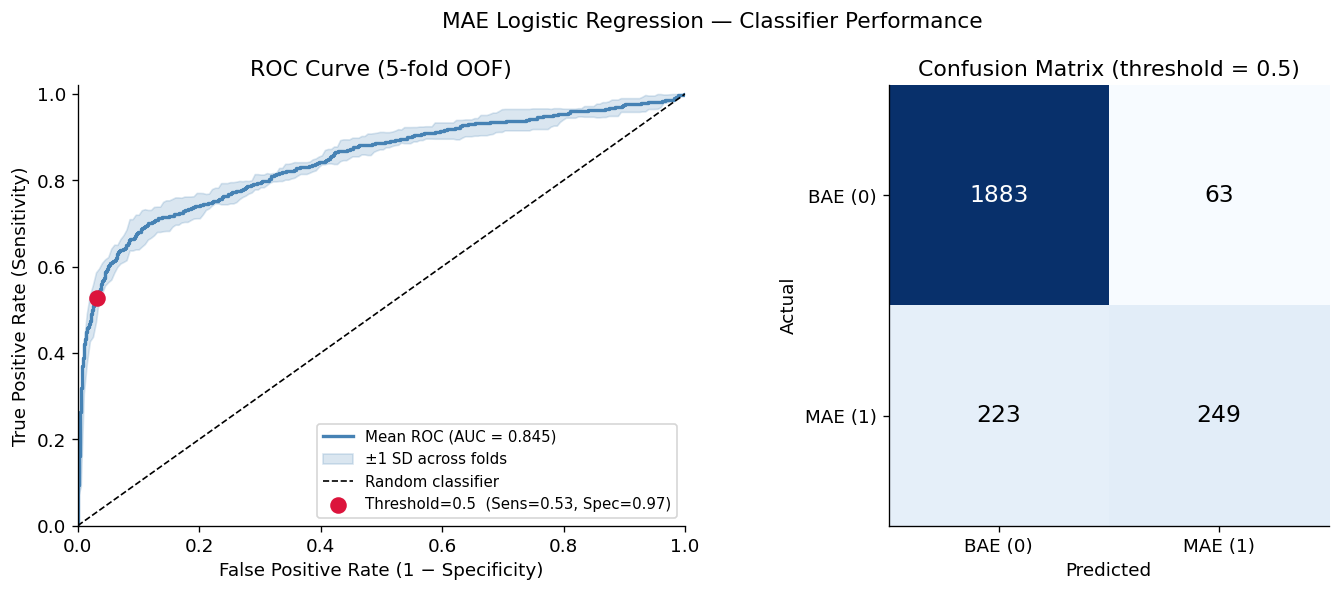

5-fold cross-validated performance (threshold = 0.5)
  AUC        : 0.845
  Sensitivity: 0.528  (true MAE correctly identified)
  Specificity: 0.968  (true BAE correctly identified)
  PPV (prec) : 0.798
  NPV        : 0.894

Full classification report:
              precision    recall  f1-score   support

         BAE       0.89      0.97      0.93      1946
         MAE       0.80      0.53      0.64       472

    accuracy                           0.88      2418
   macro avg       0.85      0.75      0.78      2418
weighted avg       0.88      0.88      0.87      2418



In [5]:
# ── ROC Curve & Classifier Performance ───────────────────────────────────────
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                              classification_report, RocCurveDisplay)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Out-of-fold predicted probabilities (gives unbiased ROC)
oof_probs = cross_val_predict(clf, X_scaled, y_train, cv=skf,
                               method='predict_proba')[:, 1]
oof_preds = (oof_probs >= 0.5).astype(int)

fpr, tpr, thresholds = roc_curve(y_train, oof_probs)
roc_auc = auc(fpr, tpr)

# Per-fold ROC for shaded band
fold_fprs, fold_tprs = [], []
for train_idx, val_idx in skf.split(X_scaled, y_train):
    clf_fold = LogisticRegression(random_state=42, max_iter=1000)
    clf_fold.fit(X_scaled[train_idx], y_train[train_idx])
    p = clf_fold.predict_proba(X_scaled[val_idx])[:, 1]
    ff, ft, _ = roc_curve(y_train[val_idx], p)
    fold_fprs.append(ff); fold_tprs.append(ft)

# Interpolate folds onto common FPR grid
mean_fpr = np.linspace(0, 1, 200)
interp_tprs = [np.interp(mean_fpr, ff, ft) for ff, ft in zip(fold_fprs, fold_tprs)]
mean_tpr  = np.mean(interp_tprs, axis=0)
std_tpr   = np.std(interp_tprs, axis=0)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('MAE Logistic Regression — Classifier Performance', fontsize=13)

# Left: ROC curve
ax = axes[0]
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'Mean ROC (AUC = {roc_auc:.3f})')
ax.fill_between(mean_fpr,
                np.clip(mean_tpr - std_tpr, 0, 1),
                np.clip(mean_tpr + std_tpr, 0, 1),
                alpha=0.2, color='steelblue', label='±1 SD across folds')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')

# Mark operating point at threshold 0.5
idx = np.argmin(np.abs(thresholds - 0.5))
ax.scatter(fpr[idx], tpr[idx], s=80, zorder=5, color='crimson',
           label=f'Threshold=0.5  (Sens={tpr[idx]:.2f}, Spec={1-fpr[idx]:.2f})')
ax.set_xlabel('False Positive Rate (1 − Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curve (5-fold OOF)')
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

# Right: Confusion matrix at threshold 0.5
ax2 = axes[1]
cm = confusion_matrix(y_train, oof_preds)
im = ax2.imshow(cm, cmap='Blues')
classes = ['BAE (0)', 'MAE (1)']
ax2.set_xticks([0, 1]); ax2.set_xticklabels(classes)
ax2.set_yticks([0, 1]); ax2.set_yticklabels(classes)
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
ax2.set_title('Confusion Matrix (threshold = 0.5)')
for i in range(2):
    for j in range(2):
        ax2.text(j, i, str(cm[i, j]), ha='center', va='center',
                 fontsize=14, color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('mae_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print summary ─────────────────────────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv         = tp / (tp + fp)
npv         = tn / (tn + fn)

print(f'5-fold cross-validated performance (threshold = 0.5)')
print(f'  AUC        : {roc_auc:.3f}')
print(f'  Sensitivity: {sensitivity:.3f}  (true MAE correctly identified)')
print(f'  Specificity: {specificity:.3f}  (true BAE correctly identified)')
print(f'  PPV (prec) : {ppv:.3f}')
print(f'  NPV        : {npv:.3f}')
print(f'\nFull classification report:')
print(classification_report(y_train, oof_preds, target_names=['BAE', 'MAE']))


In [6]:
def build_mae_pairs(pairs_df: pd.DataFrame, mae_dict: dict, prob_dict: dict) -> pd.DataFrame:
    """Return subset of pairs where BOTH genes have MAE predictions."""
    rows = []
    for _, row in pairs_df.iterrows():
        gA = str(row['gene_A']).upper()
        gB = str(row['gene_B']).upper()
        maeA = mae_dict.get(gA)
        maeB = mae_dict.get(gB)
        if maeA is not None and maeB is not None:
            both_mae  = int(maeA == 1 and maeB == 1)
            one_mae   = int(maeA != maeB)
            neither   = int(maeA == 0 and maeB == 0)
            if maeA == 1 and maeB == 1:
                pair_status = 'Both MAE'
            elif maeA == 0 and maeB == 0:
                pair_status = 'Both BAE'
            else:
                pair_status = 'One MAE'
            rows.append({
                'gene_A': row['gene_A'], 'gene_B': row['gene_B'],
                'group': row['group'],
                'mae_A': maeA, 'mae_B': maeB,
                'prob_A': prob_dict.get(gA, np.nan),
                'prob_B': prob_dict.get(gB, np.nan),
                'pair_status': pair_status,
                'n_mae': maeA + maeB,
                'concordant': int(maeA == maeB),
            })
    return pd.DataFrame(rows)

mae_pairs = build_mae_pairs(all_pairs, gene_to_mae, gene_to_mae_prob)

sig_n  = (mae_pairs['group'] == 'Significant').sum()
nsig_n = (mae_pairs['group'] == 'Non-significant').sum()
print(f'MAE analysis — sig pairs: {sig_n}, non-sig pairs: {nsig_n}')

MAE analysis — sig pairs: 34, non-sig pairs: 23598


## 4 · Copy Number Data

**Sources:**
- `OmicsAbsoluteCNGene.csv` — DepMap 24Q4 WGS-based absolute copy number (used for MCF-7; ACH-000019)
- `OmicsCNSegmentsProfile.csv` — DepMap 24Q4 SNP-array segments (all models); converted to absolute CN via MCF-7 cross-calibration (scale factor: `SegmentMean × 4.0`)
- Gene coordinates from `hg38_refseq.txt` (GRCh38 RefSeq) used to assign per-gene CN from segment midpoints

Gene-level absolute CN is built for each of the five cell lines and stored in `cn_by_cell_line`. All four cancer lines are near-tetraploid (median absolute CN ≈ 4), so CN = 2 in these cells represents allelic depletion/LOH relative to the expected ploidy, not a normal diploid state. CN is annotated on `mae_pairs` (using GM12878) and on `cell_line_scores` (each line's own CN), enabling copy-number-stratified MAE tests throughout the analyses below.


In [7]:
import os
import json as _json
import urllib.request

# ── Download DepMap 24Q4 files (only if needed) ───────────────────────────────
CN_FILE    = DATA_DIR + 'OmicsAbsoluteCNGene.csv'
MODEL_FILE = DATA_DIR + 'Model.csv'

for path, url, label in [
    (CN_FILE,    'https://ndownloader.figshare.com/files/51065303', 'OmicsAbsoluteCNGene.csv'),
    (MODEL_FILE, 'https://ndownloader.figshare.com/files/51065297', 'Model.csv'),
]:
    if not os.path.exists(path):
        print(f'Downloading {label}...', flush=True)
        urllib.request.urlretrieve(url, path)
        print(f'  Done ({os.path.getsize(path)/1e6:.0f} MB)')
    else:
        print(f'{label}: present ({os.path.getsize(path)/1e6:.0f} MB)')

# ── Load WGS absolute CN matrix (GM12878 and MCF-7 are present) ──────────────
cn_raw = pd.read_csv(CN_FILE, index_col=0)   # rows = ModelID, cols = "GENE (ENTREZID)"
models = pd.read_csv(MODEL_FILE)

def parse_gene_col(col: str) -> str:
    """Extract gene symbol from column name like 'TP53 (7157)'."""
    return col.split(' (')[0].strip().upper()

# ── CN category (works for both diploid and tetraploid contexts) ──────────────
# GM12878 is diploid  → CN=2 is normal, CN=1 is hemizygous
# Cancer lines are near-tetraploid (median CN≈4) → CN=4 is normal, CN≤2 is depleted/LOH
def cn_category(val) -> str:
    """Classify an absolute copy number value."""
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return 'unknown'
    v = round(val)
    if v <= 0:  return 'CN=0'
    if v == 1:  return 'CN=1'
    if v == 2:  return 'CN=2'
    if v == 3:  return 'CN=3'
    if v == 4:  return 'CN=4'
    return 'CN≥5'

# ── Map ENCODE cell lines → CN dicts ─────────────────────────────────────────
# GM12878, MCF-7: WGS absolute CN from OmicsAbsoluteCNGene.csv
# K562, HepG2, HCT116: pre-computed JSON (segment-based, calibrated to absolute CN)
#   Built from OmicsCNSegmentsProfile.csv × MCF-7 cross-calibration (scale = 4.0)

WGS_CELL_LINES = {
    'GM12878': 'GM12878',
    'MCF-7':   'MCF7',
    'A549':    'A549',
    'HeLa-S3': 'HELA',
    'Panc1':   'PANC1',
    'PC-3':    'PC3',
}
JSON_CN_FILES  = {
    'K562':   DATA_DIR + 'cn_genes_K562.json',
    'HepG2':  DATA_DIR + 'cn_genes_HepG2.json',
    'HCT116': DATA_DIR + 'cn_genes_HCT116.json',
    'SK-N-SH': DATA_DIR + 'cn_genes_SKNSH.json',
}

ccle_col = next(
    (c for c in ['StrippedCellLineName', 'CellLineName'] if c in models.columns), None
)
print(f'\nUsing DepMap column: {ccle_col}')

cn_by_cell_line: dict[str, dict[str, float]] = {}

# Load WGS-based CN for GM12878 and MCF-7
for encode_name, ccle_name in WGS_CELL_LINES.items():
    mask = models[ccle_col].str.upper() == ccle_name.upper()
    matches = models[mask]
    if matches.empty:
        mask2 = models[ccle_col].str.upper().str.contains(ccle_name.upper(), na=False)
        matches = models[mask2]
    if matches.empty:
        print(f'  {encode_name}: NOT FOUND in DepMap models — no CN data')
        continue
    model_id = matches.iloc[0]['ModelID']
    if model_id not in cn_raw.index:
        print(f'  {encode_name}: ModelID {model_id} not in WGS CN matrix')
        continue
    cn_dict = {
        parse_gene_col(c): float(v)
        for c, v in cn_raw.loc[model_id].items() if pd.notna(v)
    }
    cn_by_cell_line[encode_name] = cn_dict
    cn_arr = np.array(list(cn_dict.values()))
    print(f'  {encode_name:8s} → {model_id}  ({len(cn_dict):,} genes, WGS | median CN={np.median(cn_arr):.2f})')

# Load segment-calibrated CN for K562, HepG2, HCT116
for encode_name, json_path in JSON_CN_FILES.items():
    if not os.path.exists(json_path):
        print(f'  {encode_name}: JSON file missing: {json_path}')
        continue
    with open(json_path) as fh:
        raw = _json.load(fh)
    cn_dict = {g.upper(): float(v) for g, v in raw.items()}
    cn_by_cell_line[encode_name] = cn_dict
    cn_arr = np.array(list(cn_dict.values()))
    n1 = int(((cn_arr >= 0.5) & (cn_arr < 1.5)).sum())
    n2 = int(((cn_arr >= 1.5) & (cn_arr < 2.5)).sum())
    n4 = int(((cn_arr >= 3.5) & (cn_arr < 4.5)).sum())
    print(f'  {encode_name:8s} → {os.path.basename(json_path)}'
          f'  ({len(cn_dict):,} genes, segment-calibrated | '
          f'median CN={np.median(cn_arr):.2f}, CN=1:{n1}, CN=2:{n2}, CN=4:{n4})')

print(f'\nCN data loaded for: {list(cn_by_cell_line.keys())}')

# ── Annotate mae_pairs with GM12878 CN ───────────────────────────────────────
cn_gm = cn_by_cell_line.get('GM12878', {})

mae_pairs['cn_A'] = mae_pairs['gene_A'].str.upper().map(cn_gm)
mae_pairs['cn_B'] = mae_pairs['gene_B'].str.upper().map(cn_gm)
mae_pairs['cn_cat_A'] = mae_pairs['cn_A'].apply(cn_category)
mae_pairs['cn_cat_B'] = mae_pairs['cn_B'].apply(cn_category)

def pair_cn_label(cat_a: str, cat_b: str) -> str:
    if cat_a == 'CN=2' and cat_b == 'CN=2':
        return 'Both CN=2'
    if 'CN=1' in (cat_a, cat_b):
        return 'Has CN=1'
    if cat_a == 'unknown' or cat_b == 'unknown':
        return 'Unknown'
    return 'Other'

mae_pairs['cn_pair'] = mae_pairs.apply(
    lambda r: pair_cn_label(r['cn_cat_A'], r['cn_cat_B']), axis=1
)

print('\nmae_pairs CN pair label distribution (GM12878, diploid):')
print(mae_pairs.groupby(['group', 'cn_pair']).size().unstack(fill_value=0).to_string())


OmicsAbsoluteCNGene.csv: present (239 MB)
Model.csv: present (1 MB)



Using DepMap column: StrippedCellLineName
  GM12878: NOT FOUND in DepMap models — no CN data
  MCF-7    → ACH-000019  (36,700 genes, WGS | median CN=4.00)


  A549     → ACH-000681  (36,700 genes, WGS | median CN=3.00)
  HeLa-S3  → ACH-001086  (36,700 genes, WGS | median CN=3.00)
  Panc1    → ACH-000164  (36,700 genes, WGS | median CN=3.00)
  PC-3     → ACH-000090  (36,700 genes, WGS | median CN=3.00)
  K562     → cn_genes_K562.json  (19,139 genes, segment-calibrated | median CN=4.05, CN=1:11, CN=2:13, CN=4:9070)
  HepG2    → cn_genes_HepG2.json  (19,215 genes, segment-calibrated | median CN=3.76, CN=1:0, CN=2:862, CN=4:14241)


  HCT116   → cn_genes_HCT116.json  (19,215 genes, segment-calibrated | median CN=3.95, CN=1:51, CN=2:881, CN=4:17160)
  SK-N-SH  → cn_genes_SKNSH.json  (19,165 genes, segment-calibrated | median CN=3.97, CN=1:2, CN=2:126, CN=4:16479)

CN data loaded for: ['MCF-7', 'A549', 'HeLa-S3', 'Panc1', 'PC-3', 'K562', 'HepG2', 'HCT116', 'SK-N-SH']



mae_pairs CN pair label distribution (GM12878, diploid):
cn_pair          Unknown
group                   
Non-significant    23598
Significant           34


## 5 · Protein Localisation Data

**Source:** Human Protein Atlas v25 `subcellular_location.tsv`.

In [8]:
# Load Protein Atlas
with zipfile.ZipFile(DATA_DIR + 'subcellular_location.tsv.zip') as z:
    with z.open('subcellular_location.tsv') as f:
        patlas = pd.read_csv(f, sep='\t')

print(f'Protein Atlas rows: {len(patlas):,}')
print('Columns:', patlas.columns.tolist())
patlas.head(3)

Protein Atlas rows: 13,603
Columns: ['Gene', 'Gene name', 'Reliability', 'Main location', 'Additional location', 'Extracellular location', 'Enhanced', 'Supported', 'Approved', 'Uncertain', 'Single-cell variation intensity', 'Single-cell variation spatial', 'Cell cycle dependency', 'GO id']


,Gene,Gene name,Reliability,Main location,Additional location,Extracellular location,Enhanced,Supported,Approved,Uncertain,Single-cell variation intensity,Single-cell variation spatial,Cell cycle dependency,GO id
0,ENSG00000000003,TSPAN6,Approved,Cell Junctions;Cytosol,Nucleoli fibrillar center,NaN,NaN,NaN,Cell Junctions;Cytosol;Nucleoli fibrillar center,NaN,Cytosol,NaN,NaN,Cell Junctions (GO:0030054);Cytosol (GO:000582...
1,ENSG00000000457,SCYL3,Supported,Cytosol;Golgi apparatus,NaN,NaN,NaN,Cytosol;Golgi apparatus,NaN,NaN,NaN,NaN,NaN,Cytosol (GO:0005829);Golgi apparatus (GO:0005794)
2,ENSG00000000460,C1orf112,Supported,Nucleoplasm,Nucleoli,NaN,NaN,Nucleoli;Nucleoplasm,NaN,NaN,NaN,NaN,NaN,Nucleoli (GO:0005730);Nucleoplasm (GO:0005654)


In [9]:
# Build gene → set of subcellular locations
# Use both 'Main location' and 'Additional location'
def parse_locations(row):
    locs = set()
    for col in ['Main location', 'Additional location']:
        val = row.get(col, '')
        if pd.notna(val) and val:
            for loc in str(val).split(';'):
                loc = loc.strip()
                if loc:
                    locs.add(loc)
    return locs

gene_to_locs: dict[str, set] = {}
for _, row in patlas.iterrows():
    gene = str(row['Gene name']).strip().upper()
    locs = parse_locations(row)
    if gene and locs:
        gene_to_locs[gene] = locs

# Get all compartments
all_compartments = sorted(set(loc for locs in gene_to_locs.values() for loc in locs))
print(f'Genes with location data: {len(gene_to_locs):,}')
print(f'Unique compartments: {len(all_compartments)}')
print('Compartments:', all_compartments)


def jaccard(setA: set, setB: set) -> float:
    if not setA and not setB:
        return 1.0
    return len(setA & setB) / len(setA | setB)


def build_loc_pairs(pairs_df: pd.DataFrame, loc_dict: dict) -> pd.DataFrame:
    rows = []
    for _, row in pairs_df.iterrows():
        gA = str(row['gene_A']).upper()
        gB = str(row['gene_B']).upper()
        locsA = loc_dict.get(gA)
        locsB = loc_dict.get(gB)
        if locsA is not None and locsB is not None:
            jac = jaccard(locsA, locsB)
            rows.append({
                'gene_A': row['gene_A'], 'gene_B': row['gene_B'],
                'group': row['group'],
                'locs_A': locsA, 'locs_B': locsB,
                'n_locs_A': len(locsA), 'n_locs_B': len(locsB),
                'n_locs_mean': (len(locsA) + len(locsB)) / 2,
                'jaccard': jac,
            })
    return pd.DataFrame(rows)

loc_pairs = build_loc_pairs(all_pairs, gene_to_locs)

sig_n  = (loc_pairs['group'] == 'Significant').sum()
nsig_n = (loc_pairs['group'] == 'Non-significant').sum()
print(f'\nLocalisation analysis — sig pairs: {sig_n}, non-sig pairs: {nsig_n}')

Genes with location data: 13,597
Unique compartments: 49
Compartments: ['Acrosome', 'Actin filaments', 'Aggresome', 'Annulus', 'Basal body', 'Calyx', 'Cell Junctions', 'Centriolar satellite', 'Centrosome', 'Cleavage furrow', 'Connecting piece', 'Cytokinetic bridge', 'Cytoplasmic bodies', 'Cytosol', 'End piece', 'Endoplasmic reticulum', 'Endosomes', 'Equatorial segment', 'Flagellar centriole', 'Focal adhesion sites', 'Golgi apparatus', 'Intermediate filaments', 'Kinetochore', 'Lipid droplets', 'Lysosomes', 'Microtubule ends', 'Microtubules', 'Mid piece', 'Midbody', 'Midbody ring', 'Mitochondria', 'Mitotic chromosome', 'Mitotic spindle', 'Nuclear bodies', 'Nuclear membrane', 'Nuclear speckles', 'Nucleoli', 'Nucleoli fibrillar center', 'Nucleoli rim', 'Nucleoplasm', 'Perinuclear theca', 'Peroxisomes', 'Plasma membrane', 'Primary cilium', 'Primary cilium tip', 'Primary cilium transition zone', 'Principal piece', 'Rods & Rings', 'Vesicles']



Localisation analysis — sig pairs: 25, non-sig pairs: 13062


## 6 · Statistical Comparison Utilities

In [10]:
def mannwhitney_report(sig_vals, nsig_vals, metric_name: str) -> dict:
    """Run Mann-Whitney U test and return summary dict."""
    sig_vals   = np.array(sig_vals,  dtype=float)
    nsig_vals  = np.array(nsig_vals, dtype=float)
    sig_vals   = sig_vals[~np.isnan(sig_vals)]
    nsig_vals  = nsig_vals[~np.isnan(nsig_vals)]

    stat, pval = mannwhitneyu(sig_vals, nsig_vals, alternative='two-sided')

    result = {
        'Metric': metric_name,
        'Sig n': len(sig_vals),
        'Sig median': np.median(sig_vals),
        'Non-sig n': len(nsig_vals),
        'Non-sig median': np.median(nsig_vals),
        'U statistic': stat,
        'p-value': pval,
    }
    return result


def fdr_bh(p_values: list[float]) -> np.ndarray:
    """Benjamini-Hochberg FDR correction."""
    p = np.array(p_values)
    n = len(p)
    ranked = np.argsort(p)
    q = np.empty(n)
    q[ranked] = p[ranked] * n / (np.arange(n) + 1)
    # Make monotone
    for i in range(n - 2, -1, -1):
        q[ranked[i]] = min(q[ranked[i]], q[ranked[i + 1]])
    return np.minimum(q, 1.0)


all_results = []  # collect all statistical results here
print('Utility functions defined.')

Utility functions defined.


## 7 · Analysis 1 — RNA Half-Life

In [11]:
# ── Subset to sig and non-sig ─────────────────────────────────────────────────
rhl_sig   = rhl_pairs[rhl_pairs['group'] == 'Significant']
rhl_nsig  = rhl_pairs[rhl_pairs['group'] == 'Non-significant']

print(f'mRNA HL pairs — sig: {len(rhl_sig)}, non-sig: {len(rhl_nsig)}')

# ── Tests ─────────────────────────────────────────────────────────────────────
r1 = mannwhitney_report(rhl_sig['hl_diff'],  rhl_nsig['hl_diff'],  'RNA HL | Within-pair |diff|')
r2 = mannwhitney_report(rhl_sig['hl_mean'],  rhl_nsig['hl_mean'],  'RNA HL | Pair mean HL')
r3 = mannwhitney_report(rhl_sig[['hl_A','hl_B']].values.flatten(),
                         rhl_nsig[['hl_A','hl_B']].values.flatten(),
                         'RNA HL | Per-gene HL')
all_results.extend([r1, r2, r3])

for r in [r1, r2, r3]:
    print(f"{r['Metric']:45s}  sig median={r['Sig median']:.2f}  nsig median={r['Non-sig median']:.2f}  p={r['p-value']:.4g}")

mRNA HL pairs — sig: 26, non-sig: 7904
RNA HL | Within-pair |diff|                    sig median=2.79  nsig median=2.38  p=0.8332
RNA HL | Pair mean HL                          sig median=7.49  nsig median=5.21  p=0.005368
RNA HL | Per-gene HL                           sig median=7.32  nsig median=4.00  p=0.0001225


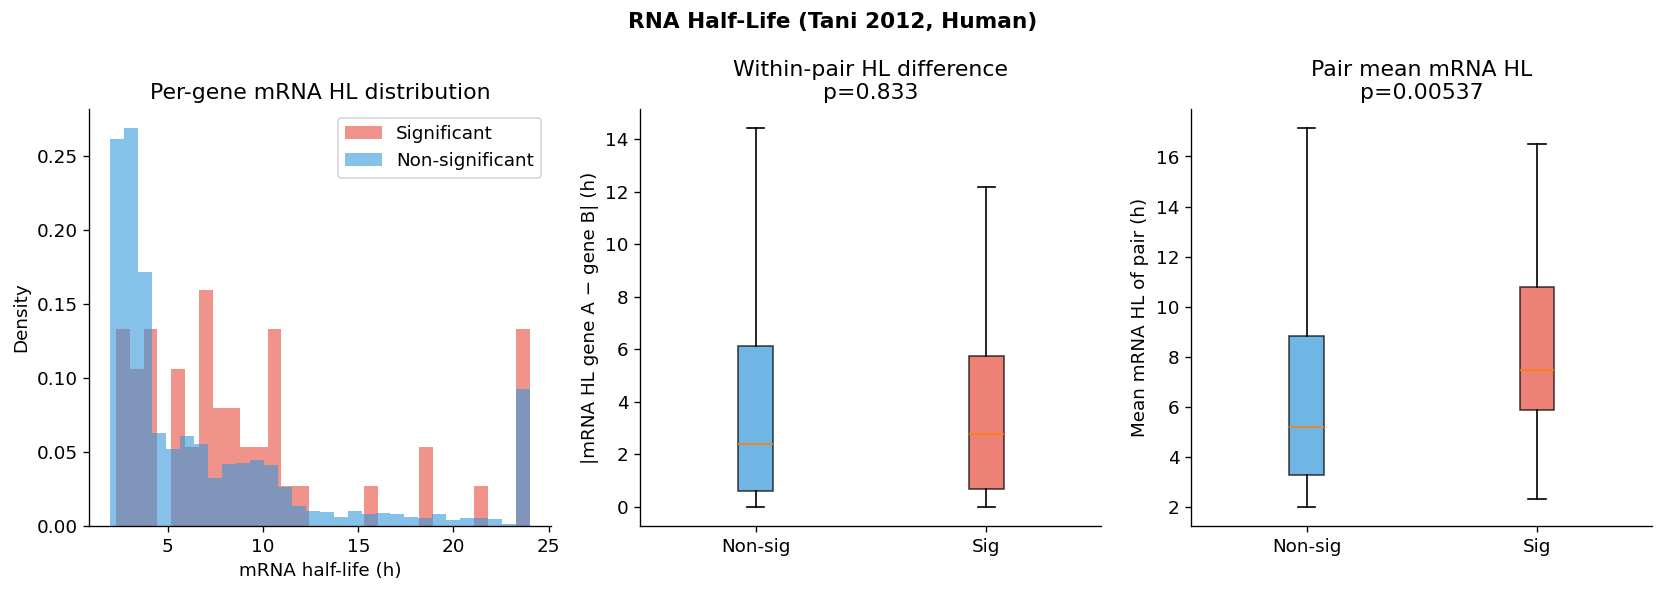

Figure saved: rna_halflife_analysis.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('RNA Half-Life (Tani 2012, Human)', fontsize=13, fontweight='bold')

palette = {'Significant': SIG_COLOR, 'Non-significant': NSIG_COLOR}

# Per-gene HL distribution
ax = axes[0]
for grp, color in palette.items():
    subset = rhl_pairs[rhl_pairs['group'] == grp]
    vals = np.concatenate([subset['hl_A'].values, subset['hl_B'].values])
    ax.hist(vals, bins=30, alpha=0.6, color=color, label=grp, density=True)
ax.set_xlabel('mRNA half-life (h)')
ax.set_ylabel('Density')
ax.set_title('Per-gene mRNA HL distribution')
ax.legend()

# Within-pair difference
ax = axes[1]
data_box = [rhl_nsig['hl_diff'].values, rhl_sig['hl_diff'].values]
bp = ax.boxplot(data_box, labels=['Non-sig', 'Sig'], patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], [NSIG_COLOR, SIG_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('|mRNA HL gene A − gene B| (h)')
ax.set_title(f'Within-pair HL difference\np={r1["p-value"]:.3g}')

# Pair mean HL
ax = axes[2]
data_box = [rhl_nsig['hl_mean'].values, rhl_sig['hl_mean'].values]
bp = ax.boxplot(data_box, labels=['Non-sig', 'Sig'], patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], [NSIG_COLOR, SIG_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Mean mRNA HL of pair (h)')
ax.set_title(f'Pair mean mRNA HL\np={r2["p-value"]:.3g}')

plt.tight_layout()
plt.savefig('rna_halflife_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: rna_halflife_analysis.png')


## 8 · Analysis 2 — Protein Half-Life

In [13]:
phl_sig   = phl_pairs[phl_pairs['group'] == 'Significant']
phl_nsig  = phl_pairs[phl_pairs['group'] == 'Non-significant']

print(f'Protein HL pairs — sig: {len(phl_sig)}, non-sig: {len(phl_nsig)}')

r4 = mannwhitney_report(phl_sig['hl_diff'],  phl_nsig['hl_diff'],  'Protein HL | Within-pair |diff|')
r5 = mannwhitney_report(phl_sig['hl_mean'],  phl_nsig['hl_mean'],  'Protein HL | Pair mean HL')
r6 = mannwhitney_report(phl_sig[['hl_A','hl_B']].values.flatten(),
                         phl_nsig[['hl_A','hl_B']].values.flatten(),
                         'Protein HL | Per-gene HL')
all_results.extend([r4, r5, r6])

for r in [r4, r5, r6]:
    print(f"{r['Metric']:45s}  sig median={r['Sig median']:.2f}  nsig median={r['Non-sig median']:.2f}  p={r['p-value']:.4g}")

Protein HL pairs — sig: 23, non-sig: 3970
Protein HL | Within-pair |diff|                sig median=40.06  nsig median=49.55  p=0.4947
Protein HL | Pair mean HL                      sig median=105.73  nsig median=100.93  p=0.7224
Protein HL | Per-gene HL                       sig median=110.16  nsig median=91.60  p=0.3354


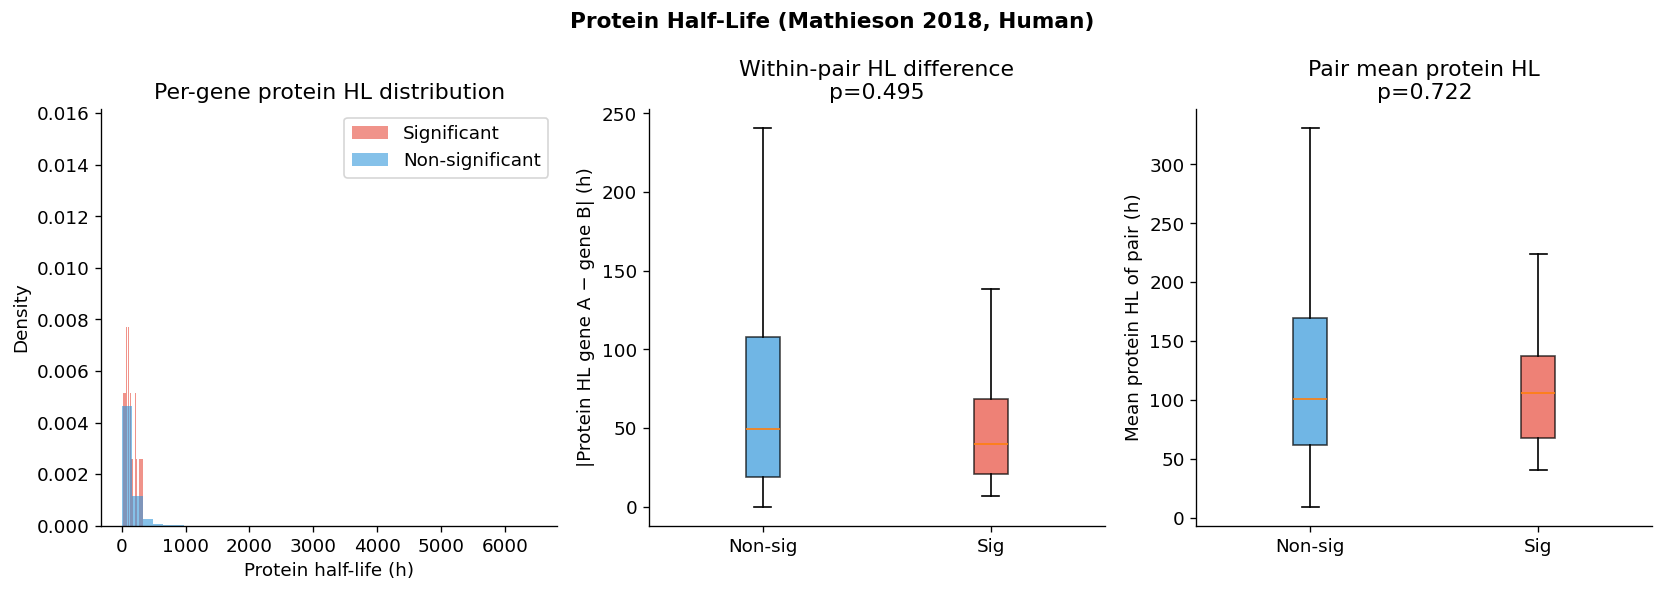

Figure saved: protein_halflife_analysis.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Protein Half-Life (Mathieson 2018, Human)', fontsize=13, fontweight='bold')

# Per-gene protein HL distribution
ax = axes[0]
for grp, color in palette.items():
    subset = phl_pairs[phl_pairs['group'] == grp]
    vals = np.concatenate([subset['hl_A'].values, subset['hl_B'].values])
    ax.hist(vals, bins=40, alpha=0.6, color=color, label=grp, density=True)
ax.set_xlabel('Protein half-life (h)')
ax.set_ylabel('Density')
ax.set_title('Per-gene protein HL distribution')
ax.legend()

# Within-pair difference
ax = axes[1]
data_box = [phl_nsig['hl_diff'].values, phl_sig['hl_diff'].values]
bp = ax.boxplot(data_box, labels=['Non-sig', 'Sig'], patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], [NSIG_COLOR, SIG_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('|Protein HL gene A − gene B| (h)')
ax.set_title(f'Within-pair HL difference\np={r4["p-value"]:.3g}')

# Pair mean protein HL
ax = axes[2]
data_box = [phl_nsig['hl_mean'].values, phl_sig['hl_mean'].values]
bp = ax.boxplot(data_box, labels=['Non-sig', 'Sig'], patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], [NSIG_COLOR, SIG_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Mean protein HL of pair (h)')
ax.set_title(f'Pair mean protein HL\np={r5["p-value"]:.3g}')

plt.tight_layout()
plt.savefig('protein_halflife_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: protein_halflife_analysis.png')


## 9 · Analysis 3 — Mono-Allelic Expression

In [15]:
mae_sig   = mae_pairs[mae_pairs['group'] == 'Significant']
mae_nsig  = mae_pairs[mae_pairs['group'] == 'Non-significant']

status_cats = ['Both MAE', 'One MAE', 'Both BAE']

def run_mae_tests(sig_df, nsig_df, label=''):
    """Run chi-squared (pair status) + Mann-Whitney (per-gene prob) on a subset."""
    if len(sig_df) < 3 or len(nsig_df) < 3:
        print(f'\n── {label} ──  SKIPPED (sig={len(sig_df)}, nsig={len(nsig_df)} — insufficient data)')
        ct_empty = pd.Series({'Both MAE': 0, 'One MAE': 0, 'Both BAE': 0})
        dummy_r = {'p-value': np.nan, 'Sig median': np.nan, 'Non-sig median': np.nan,
                   'Metric': label, 'Sig n': len(sig_df), 'Non-sig n': len(nsig_df)}
        return np.nan, np.nan, dummy_r, ct_empty, ct_empty, np.array([]), np.array([])
    ct_sig  = sig_df['pair_status'].value_counts().reindex(status_cats, fill_value=0)
    ct_nsig = nsig_df['pair_status'].value_counts().reindex(status_cats, fill_value=0)
    chi2_val, p_chi2_val, dof, _ = chi2_contingency(
        np.array([ct_sig.values, ct_nsig.values])
    )
    sig_probs  = np.concatenate([sig_df['prob_A'].dropna().values,
                                  sig_df['prob_B'].dropna().values])
    nsig_probs = np.concatenate([nsig_df['prob_A'].dropna().values,
                                  nsig_df['prob_B'].dropna().values])
    r = mannwhitney_report(sig_probs, nsig_probs, f'MAE [{label}] | Per-gene MAE prob')
    print(f'\n── {label} ──  sig pairs={len(sig_df)}, nsig pairs={len(nsig_df)}')
    ct_df = pd.DataFrame({'Sig': ct_sig, 'Non-sig': ct_nsig})
    print(ct_df.to_string())
    print(f'Chi-squared: χ²={chi2_val:.3f}, df={dof}, p={p_chi2_val:.4g}')
    print(f'Per-gene MAE prob: sig median={r["Sig median"]:.3f}  '
          f'nsig median={r["Non-sig median"]:.3f}  p={r["p-value"]:.4g}')
    return chi2_val, p_chi2_val, r, ct_sig, ct_nsig, sig_probs, nsig_probs

# ── All genes (no CN filter) ─────────────────────────────────────────────────
chi2, p_chi2, r7, ct_sig, ct_nsig, sig_probs, nsig_probs = run_mae_tests(
    mae_sig, mae_nsig, 'All genes'
)

# ── CN = 2 only (diploid — true epigenetic MAE) ───────────────────────────────
mae_sig_cn2  = mae_sig[mae_sig['cn_pair'] == 'Both CN=2']
mae_nsig_cn2 = mae_nsig[mae_nsig['cn_pair'] == 'Both CN=2']
chi2_cn2, p_chi2_cn2, r7_cn2, ct_sig_cn2, ct_nsig_cn2, sig_probs_cn2, nsig_probs_cn2 = (
    run_mae_tests(mae_sig_cn2, mae_nsig_cn2, 'CN=2 only (diploid)')
)
cn2_available = len(mae_sig_cn2) >= 3 and len(mae_nsig_cn2) >= 3

# ── CN = 1 (at least one hemizygous gene) ────────────────────────────────────
mae_sig_cn1  = mae_sig[mae_sig['cn_pair'] == 'Has CN=1']
mae_nsig_cn1 = mae_nsig[mae_nsig['cn_pair'] == 'Has CN=1']
if len(mae_sig_cn1) >= 3 and len(mae_nsig_cn1) >= 3:
    run_mae_tests(mae_sig_cn1, mae_nsig_cn1, 'Has CN=1 (hemizygous)')

# ── Concordance (all genes) ───────────────────────────────────────────────────
r8 = mannwhitney_report(mae_sig['concordant'].values, mae_nsig['concordant'].values,
                         'MAE | Pair concordance (both same MAE/BAE)')
all_results.extend([r7, r8])

r8_chi = {'Metric': 'MAE | Chi-squared on pair-status distribution',
           'Sig n': len(mae_sig), 'Non-sig n': len(mae_nsig),
           'chi2': chi2, 'p-value': p_chi2}



── All genes ──  sig pairs=34, nsig pairs=23598
             Sig  Non-sig
pair_status              
Both MAE       0    10443
One MAE        8     7366
Both BAE      26     5789
Chi-squared: χ²=52.910, df=2, p=3.241e-12
Per-gene MAE prob: sig median=0.060  nsig median=0.751  p=7.043e-19

── CN=2 only (diploid) ──  SKIPPED (sig=0, nsig=0 — insufficient data)


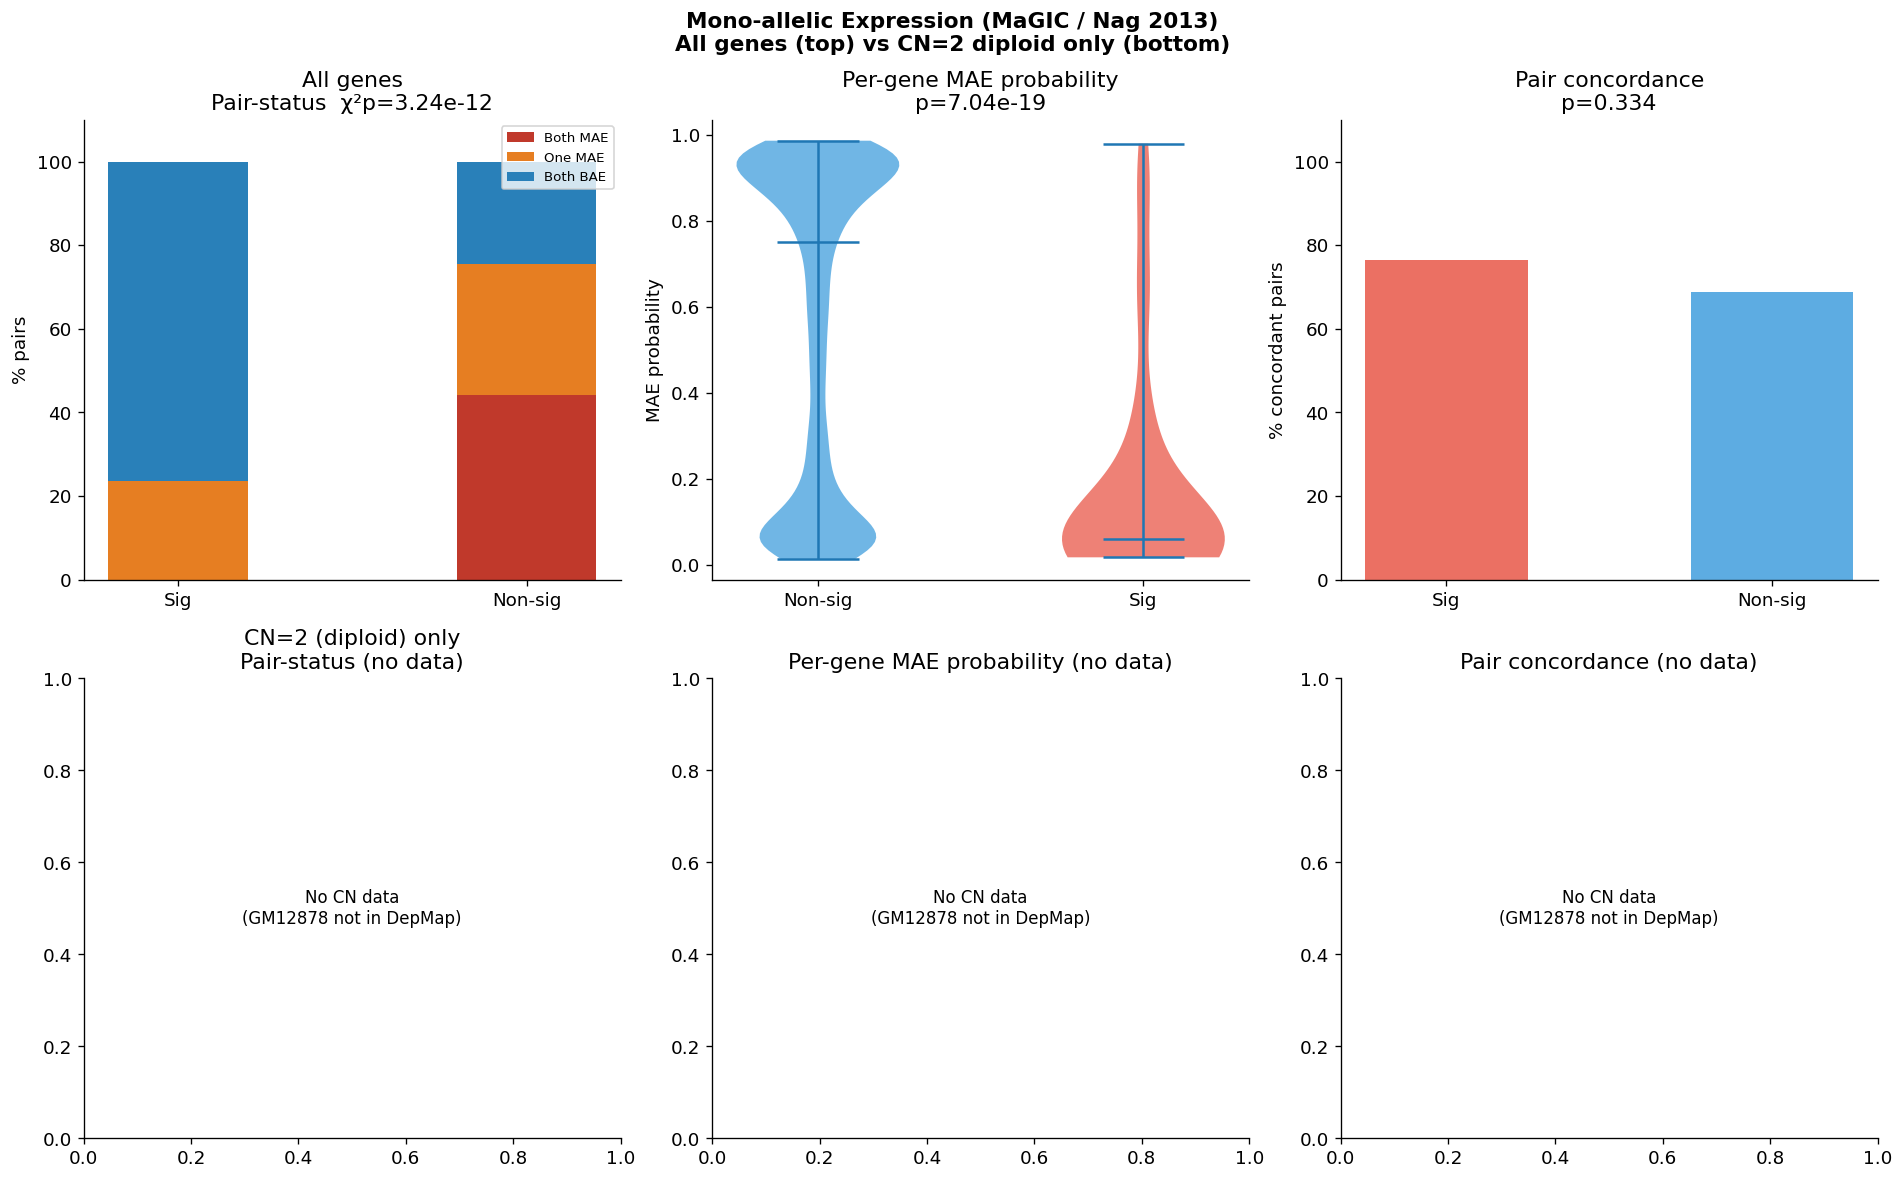

Figure saved: mae_analysis.png


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Mono-allelic Expression (MaGIC / Nag 2013)\nAll genes (top) vs CN=2 diploid only (bottom)',
             fontsize=13, fontweight='bold')

def mae_figure_row(axes_row, sig_df, nsig_df, ct_s, ct_ns, s_probs, ns_probs,
                   p_chi2_val, r_prob, row_label):
    status_cats_local = ['Both MAE', 'One MAE', 'Both BAE']
    status_colors = {'Both MAE': '#C0392B', 'One MAE': '#E67E22', 'Both BAE': '#2980B9'}
    no_data = len(s_probs) == 0 or len(ns_probs) == 0

    # Panel A: stacked bar — pair status
    ax = axes_row[0]
    if not no_data:
        ct_pct_sig  = ct_s  / ct_s.sum()  * 100
        ct_pct_nsig = ct_ns / ct_ns.sum() * 100
        b_sig = b_ns = 0
        for status in status_cats_local:
            ax.bar([0], [ct_pct_sig[status]],  bottom=[b_sig],
                   color=status_colors[status], label=status, width=0.4)
            ax.bar([1], [ct_pct_nsig[status]], bottom=[b_ns],
                   color=status_colors[status], width=0.4)
            b_sig += ct_pct_sig[status]
            b_ns  += ct_pct_nsig[status]
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Sig', 'Non-sig'])
        ax.set_ylabel('% pairs')
        ax.set_title(f'{row_label}\nPair-status  χ²p={p_chi2_val:.3g}')
        ax.legend(loc='upper right', fontsize=8)
        ax.set_ylim(0, 110)
    else:
        ax.text(0.5, 0.5, 'No CN data\n(GM12878 not in DepMap)',
                ha='center', va='center', transform=ax.transAxes, fontsize=10)
        ax.set_title(f'{row_label}\nPair-status (no data)')

    # Panel B: violin — per-gene MAE probability
    ax = axes_row[1]
    if not no_data:
        parts = ax.violinplot([ns_probs, s_probs], positions=[0, 1], showmedians=True)
        for pc, color in zip(parts['bodies'], [NSIG_COLOR, SIG_COLOR]):
            pc.set_facecolor(color); pc.set_alpha(0.7)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Non-sig', 'Sig'])
        ax.set_ylabel('MAE probability')
        ax.set_title(f'Per-gene MAE probability\np={r_prob["p-value"]:.3g}')
    else:
        ax.text(0.5, 0.5, 'No CN data\n(GM12878 not in DepMap)',
                ha='center', va='center', transform=ax.transAxes, fontsize=10)
        ax.set_title('Per-gene MAE probability (no data)')

    # Panel C: concordance
    ax = axes_row[2]
    if not no_data:
        conc_sig  = sig_df['concordant'].mean()  * 100
        conc_nsig = nsig_df['concordant'].mean() * 100
        r_conc = mannwhitney_report(sig_df['concordant'].values, nsig_df['concordant'].values,
                                     'concordance')
        ax.bar(['Sig', 'Non-sig'], [conc_sig, conc_nsig],
               color=[SIG_COLOR, NSIG_COLOR], alpha=0.8, width=0.5)
        ax.set_ylabel('% concordant pairs')
        ax.set_title(f'Pair concordance\np={r_conc["p-value"]:.3g}')
        ax.set_ylim(0, 110)
    else:
        ax.text(0.5, 0.5, 'No CN data\n(GM12878 not in DepMap)',
                ha='center', va='center', transform=ax.transAxes, fontsize=10)
        ax.set_title('Pair concordance (no data)')

# Top row: all genes
mae_figure_row(axes[0], mae_sig, mae_nsig, ct_sig, ct_nsig,
               sig_probs, nsig_probs, p_chi2, r7, 'All genes')

# Bottom row: CN=2 only (or note if unavailable)
mae_figure_row(axes[1], mae_sig_cn2, mae_nsig_cn2, ct_sig_cn2, ct_nsig_cn2,
               sig_probs_cn2, nsig_probs_cn2, p_chi2_cn2, r7_cn2, 'CN=2 (diploid) only')

plt.tight_layout()
plt.savefig('mae_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: mae_analysis.png')


## 10 · Analysis 4 — Protein Localisation

In [17]:
loc_sig   = loc_pairs[loc_pairs['group'] == 'Significant']
loc_nsig  = loc_pairs[loc_pairs['group'] == 'Non-significant']

print(f'Localisation pairs — sig: {len(loc_sig)}, non-sig: {len(loc_nsig)}')

# ── a. Jaccard similarity ─────────────────────────────────────────────────────
r9  = mannwhitney_report(loc_sig['jaccard'],      loc_nsig['jaccard'],      'Localisation | Jaccard similarity')

# ── b. Number of compartments per gene ───────────────────────────────────────
r10 = mannwhitney_report(
    np.concatenate([loc_sig['n_locs_A'].values,  loc_sig['n_locs_B'].values]),
    np.concatenate([loc_nsig['n_locs_A'].values, loc_nsig['n_locs_B'].values]),
    'Localisation | Compartment count per gene'
)
r11 = mannwhitney_report(loc_sig['n_locs_mean'],  loc_nsig['n_locs_mean'],
                          'Localisation | Mean compartment count per pair')

all_results.extend([r9, r10, r11])

for r in [r9, r10, r11]:
    print(f"{r['Metric']:55s}  sig median={r['Sig median']:.3f}  nsig median={r['Non-sig median']:.3f}  p={r['p-value']:.4g}")

Localisation pairs — sig: 25, non-sig: 13062
Localisation | Jaccard similarity                        sig median=0.500  nsig median=0.250  p=0.0075
Localisation | Compartment count per gene                sig median=2.000  nsig median=2.000  p=0.5799
Localisation | Mean compartment count per pair           sig median=2.000  nsig median=2.000  p=0.9504


In [18]:
# ── c. Per-compartment Fisher's exact test ───────────────────────────────────

def gene_has_compartment(gene_locs_series: pd.Series, compartment: str) -> np.ndarray:
    return np.array([compartment in locs for locs in gene_locs_series])

compartment_results = []
for comp in all_compartments:
    # All genes in sig pairs
    sig_genes_locs  = list(loc_sig['locs_A']) + list(loc_sig['locs_B'])
    nsig_genes_locs = list(loc_nsig['locs_A']) + list(loc_nsig['locs_B'])

    sig_in  = sum(comp in l for l in sig_genes_locs)
    sig_out = len(sig_genes_locs) - sig_in
    ns_in   = sum(comp in l for l in nsig_genes_locs)
    ns_out  = len(nsig_genes_locs) - ns_in

    table = [[sig_in, sig_out], [ns_in, ns_out]]
    _, p = fisher_exact(table, alternative='two-sided')

    compartment_results.append({
        'Compartment': comp,
        'Sig % with compartment': 100 * sig_in / len(sig_genes_locs) if sig_genes_locs else 0,
        'Non-sig % with compartment': 100 * ns_in / len(nsig_genes_locs) if nsig_genes_locs else 0,
        'Sig count': sig_in,
        'Non-sig count': ns_in,
        'p-value': p,
    })

comp_df = pd.DataFrame(compartment_results).sort_values('p-value')
comp_df['q-value (BH)'] = fdr_bh(comp_df['p-value'].tolist())
comp_df['p-value'] = comp_df['p-value'].round(4)
comp_df['q-value (BH)'] = comp_df['q-value (BH)'].round(4)

print('Per-compartment Fisher exact results (sorted by p-value):')
print(comp_df[['Compartment', 'Sig % with compartment', 'Non-sig % with compartment', 'p-value', 'q-value (BH)']].to_string(index=False))

Per-compartment Fisher exact results (sorted by p-value):
                   Compartment  Sig % with compartment  Non-sig % with compartment  p-value  q-value (BH)
           Flagellar centriole                    12.0                    1.025877   0.0000        0.0007
               Mitotic spindle                     8.0                    1.071811   0.0021        0.0516
                     End piece                    10.0                    1.982851   0.0032        0.0516
            Primary cilium tip                     8.0                    1.370387   0.0050        0.0615
                    Basal body                    12.0                    3.525494   0.0082        0.0802
            Cytokinetic bridge                     8.0                    2.266115   0.0269        0.2194
                  Microtubules                     8.0                    3.012556   0.0639        0.4276
                Primary cilium                    10.0                    4.562854   0.0773   

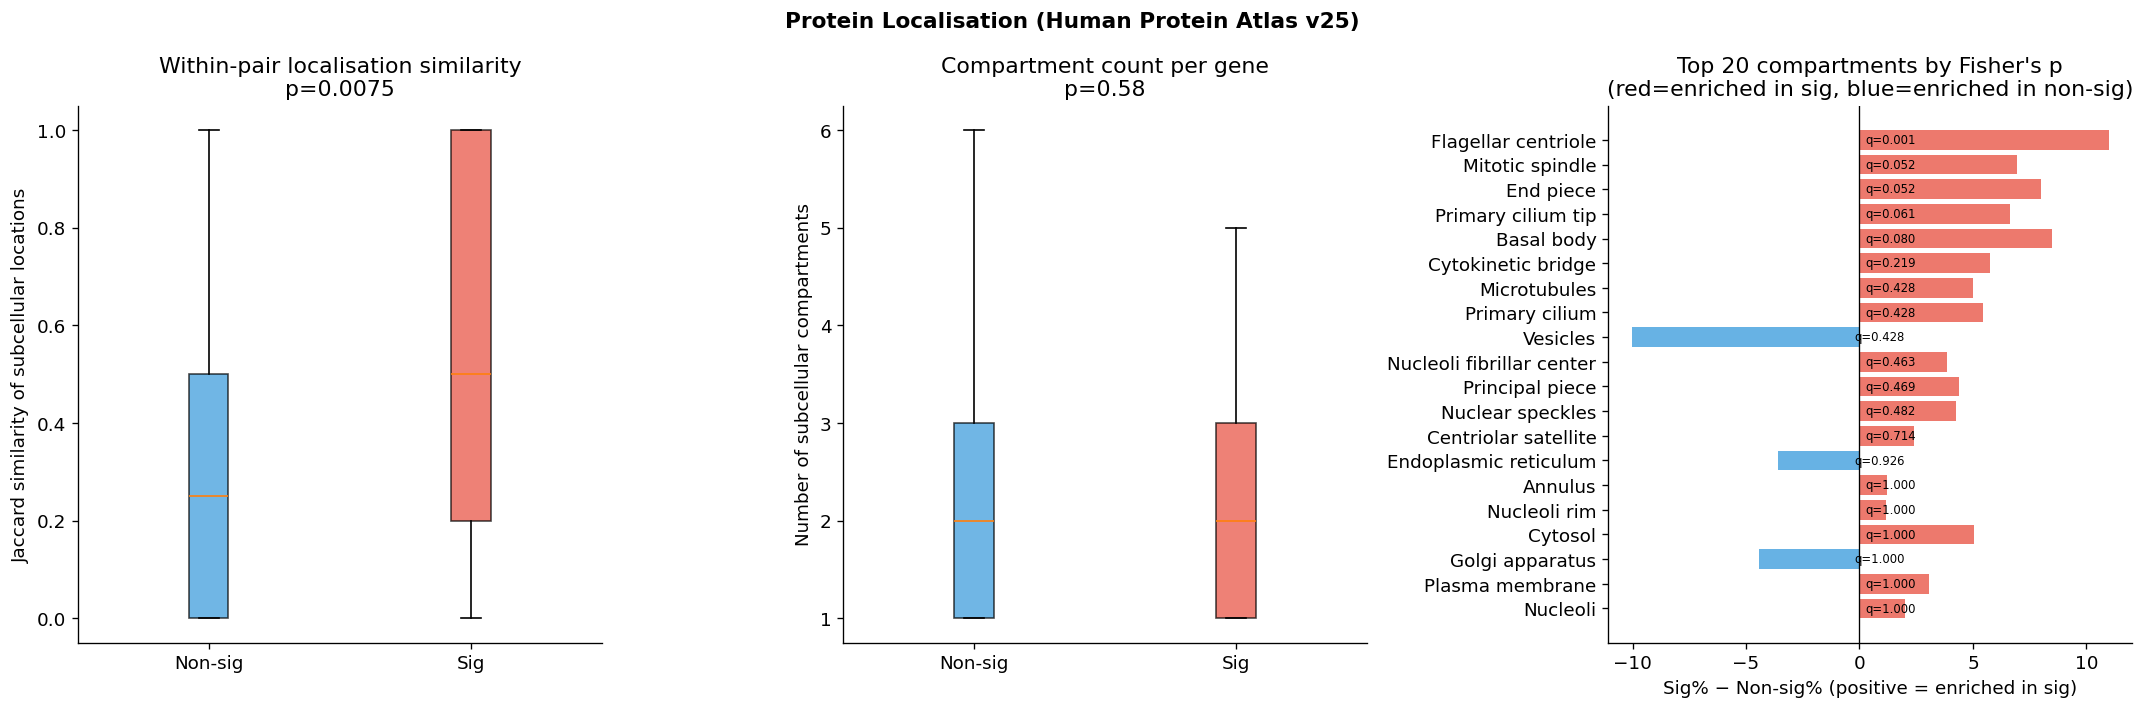

Figure saved: localisation_analysis.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Protein Localisation (Human Protein Atlas v25)', fontsize=13, fontweight='bold')

# Jaccard similarity
ax = axes[0]
data_box = [loc_nsig['jaccard'].values, loc_sig['jaccard'].values]
bp = ax.boxplot(data_box, labels=['Non-sig', 'Sig'], patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], [NSIG_COLOR, SIG_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Jaccard similarity of subcellular locations')
ax.set_title(f'Within-pair localisation similarity\np={r9["p-value"]:.3g}')

# Compartment count per gene
ax = axes[1]
sig_n_locs   = np.concatenate([loc_sig['n_locs_A'].values,  loc_sig['n_locs_B'].values])
nsig_n_locs  = np.concatenate([loc_nsig['n_locs_A'].values, loc_nsig['n_locs_B'].values])
data_box = [nsig_n_locs, sig_n_locs]
bp = ax.boxplot(data_box, labels=['Non-sig', 'Sig'], patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], [NSIG_COLOR, SIG_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Number of subcellular compartments')
ax.set_title(f'Compartment count per gene\np={r10["p-value"]:.3g}')

# Per-compartment enrichment heatmap (top 20 by p-value)
ax = axes[2]
top20 = comp_df.head(20).copy()
bar_colors = [SIG_COLOR if row['Sig % with compartment'] > row['Non-sig % with compartment']
              else NSIG_COLOR for _, row in top20.iterrows()]
bars = ax.barh(
    top20['Compartment'],
    top20['Sig % with compartment'] - top20['Non-sig % with compartment'],
    color=bar_colors, alpha=0.75
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Sig% − Non-sig% (positive = enriched in sig)')
ax.set_title('Top 20 compartments by Fisher\'s p\n(red=enriched in sig, blue=enriched in non-sig)')
ax.invert_yaxis()

# Annotate q-values
for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(ax.get_xlim()[1] * 0.02 if row['Sig % with compartment'] > row['Non-sig % with compartment']
            else ax.get_xlim()[0] * 0.02,
            i, f"q={row['q-value (BH)']:.3f}", va='center', fontsize=7)

plt.tight_layout()
plt.savefig('localisation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: localisation_analysis.png')

## 11 · MAE Analysis Across 10 Cell Lines

The GM12878-trained MAE classifier is applied to nine additional cell lines using H3K27me3/H3K36me3 ENCODE BigWig signals (GRCh38, fold change over control), converted to within-cell-line percentile ranks before classification.

| Cell line | Cancer type |
|---|---|
| GM12878 | Normal lymphoblast (baseline) |
| K562 | CML leukaemia |
| HepG2 | Hepatocellular carcinoma |
| HCT116 | Colorectal carcinoma |
| MCF-7 | Breast adenocarcinoma |
| A549 | Lung adenocarcinoma |
| HeLa-S3 | Cervical carcinoma |
| Panc1 | Pancreatic carcinoma |
| SK-N-SH | Neuroblastoma |
| PC-3 | Prostate carcinoma |

Sig vs non-sig paralog MAE probabilities are compared per cell line (Mann-Whitney), and MAE state stability is tested by paired Wilcoxon (GM12878 → each cancer line). All tests are repeated on the CN = 2 (LOH/depleted) subset to confirm the signal is independent of local copy number context.


In [20]:
import pyBigWig
import urllib.request
import os

BIGWIG_DIR = DATA_DIR + 'bigwig/'

# ── ENCODE BigWig files: H3K27me3 and H3K36me3 (fold change over control, GRCh38) ──
ENCODE_FILES = {
    'GM12878': {
        'H3K27me3': BIGWIG_DIR + 'ENCFF543IHG.bigWig',   # ENCSR000DRX
        'H3K36me3': BIGWIG_DIR + 'ENCFF269OIU.bigWig',
    },
    'K562': {
        'H3K27me3': BIGWIG_DIR + 'ENCFF517ZXO.bigWig',   # ENCSR000EWB
        'H3K36me3': BIGWIG_DIR + 'ENCFF743PWK.bigWig',
    },
    'HepG2': {
        'H3K27me3': BIGWIG_DIR + 'ENCFF529HLC.bigWig',   # ENCSR000DUE
        'H3K36me3': BIGWIG_DIR + 'ENCFF247LOP.bigWig',
    },
    'HCT116': {
        'H3K27me3': BIGWIG_DIR + 'ENCFF717ZKL.bigWig',   # ENCSR810BDB (pooled)
        'H3K36me3': BIGWIG_DIR + 'ENCFF024LGD.bigWig',
    },
    'MCF-7': {
        'H3K27me3': BIGWIG_DIR + 'ENCFF725VID.bigWig',   # ENCSR761DLU
        'H3K36me3': BIGWIG_DIR + 'ENCFF849SIF.bigWig',
    },
    'A549': {
        'H3K27me3': BIGWIG_DIR + 'ENCFF702IOJ.bigWig',   # ENCSR000AUJ (lung adenocarcinoma)
        'H3K36me3': BIGWIG_DIR + 'ENCFF473XIC.bigWig',   # ENCSR000AUL
    },
    'HeLa-S3': {
        'H3K27me3': BIGWIG_DIR + 'ENCFF772IJJ.bigWig',   # ENCSR000DTY (cervical carcinoma)
        'H3K36me3': BIGWIG_DIR + 'ENCFF521FCP.bigWig',   # ENCSR000DTZ
    },
    'Panc1': {
        'H3K27me3': BIGWIG_DIR + 'ENCFF248QSM.bigWig',   # ENCSR000FCO (pancreatic carcinoma)
        'H3K36me3': BIGWIG_DIR + 'ENCFF924OSQ.bigWig',   # ENCSR000FCM
    },
    'SK-N-SH': {
        'H3K27me3': BIGWIG_DIR + 'ENCFF224TVD.bigWig',   # ENCSR914QOK (neuroblastoma)
        'H3K36me3': BIGWIG_DIR + 'ENCFF681BMN.bigWig',   # ENCSR978CNH
    },
    'PC-3': {
        'H3K27me3': BIGWIG_DIR + 'ENCFF635DUG.bigWig',   # ENCSR881TWJ (prostate carcinoma)
        'H3K36me3': BIGWIG_DIR + 'ENCFF840SKF.bigWig',   # ENCSR849APH
    },
}

# ENCODE download URLs — only files not already present need listing here
ENCODE_URLS = {
    'ENCFF529HLC': 'https://www.encodeproject.org/files/ENCFF529HLC/@@download/ENCFF529HLC.bigWig',
    'ENCFF247LOP': 'https://www.encodeproject.org/files/ENCFF247LOP/@@download/ENCFF247LOP.bigWig',
    'ENCFF717ZKL': 'https://www.encodeproject.org/files/ENCFF717ZKL/@@download/ENCFF717ZKL.bigWig',
    'ENCFF024LGD': 'https://www.encodeproject.org/files/ENCFF024LGD/@@download/ENCFF024LGD.bigWig',
    'ENCFF725VID': 'https://www.encodeproject.org/files/ENCFF725VID/@@download/ENCFF725VID.bigWig',
    'ENCFF849SIF': 'https://www.encodeproject.org/files/ENCFF849SIF/@@download/ENCFF849SIF.bigWig',
    'ENCFF702IOJ': 'https://www.encodeproject.org/files/ENCFF702IOJ/@@download/ENCFF702IOJ.bigWig',
    'ENCFF473XIC': 'https://www.encodeproject.org/files/ENCFF473XIC/@@download/ENCFF473XIC.bigWig',
    'ENCFF772IJJ': 'https://www.encodeproject.org/files/ENCFF772IJJ/@@download/ENCFF772IJJ.bigWig',
    'ENCFF521FCP': 'https://www.encodeproject.org/files/ENCFF521FCP/@@download/ENCFF521FCP.bigWig',
    'ENCFF248QSM': 'https://www.encodeproject.org/files/ENCFF248QSM/@@download/ENCFF248QSM.bigWig',
    'ENCFF924OSQ': 'https://www.encodeproject.org/files/ENCFF924OSQ/@@download/ENCFF924OSQ.bigWig',
    'ENCFF224TVD': 'https://www.encodeproject.org/files/ENCFF224TVD/@@download/ENCFF224TVD.bigWig',
    'ENCFF681BMN': 'https://www.encodeproject.org/files/ENCFF681BMN/@@download/ENCFF681BMN.bigWig',
    'ENCFF635DUG': 'https://www.encodeproject.org/files/ENCFF635DUG/@@download/ENCFF635DUG.bigWig',
    'ENCFF840SKF': 'https://www.encodeproject.org/files/ENCFF840SKF/@@download/ENCFF840SKF.bigWig',
}

# Download any missing BigWig files
for accession, url in ENCODE_URLS.items():
    dest = BIGWIG_DIR + accession + '.bigWig'
    if not os.path.exists(dest):
        print(f'Downloading {accession}...', end=' ', flush=True)
        urllib.request.urlretrieve(url, dest)
        print(f'done ({os.path.getsize(dest)/1e6:.0f} MB)')
    else:
        print(f'{accession}: already present ({os.path.getsize(dest)/1e6:.0f} MB)')

# ── Load GRCh38 RefSeq gene coordinates ──────────────────────────────────────
refseq = pd.read_csv(
    DATA_DIR + 'hg38_refseq.txt', sep='\t', comment='#',
    names=['bin','name','chrom','strand','txStart','txEnd',
           'cdsStart','cdsEnd','exonCount','exonStarts','exonEnds',
           'score','name2','cdsStartStat','cdsEndStat']
)

# Keep protein-coding transcripts on standard chromosomes; one longest tx per gene
refseq = refseq[refseq['chrom'].str.match(r'^chr[\dXY]+$')]
refseq['tx_len'] = refseq['txEnd'] - refseq['txStart']
gene_coords = (
    refseq.sort_values('tx_len', ascending=False)
          .drop_duplicates(subset='name2')
          [['name2', 'chrom', 'txStart', 'txEnd']]
          .rename(columns={'name2': 'gene'})
          .reset_index(drop=True)
)

print(f'\nUnique genes in GRCh38 RefSeq: {len(gene_coords):,}')
print(gene_coords.head(3))


def compute_gene_body_score(bw_path: str, gene_coords_df: pd.DataFrame) -> dict[str, float]:
    """Return mean BigWig signal over each gene body."""
    bw = pyBigWig.open(bw_path)
    scores = {}
    for _, row in gene_coords_df.iterrows():
        try:
            val = bw.stats(row['chrom'], int(row['txStart']), int(row['txEnd']), type='mean')[0]
            if val is not None:
                scores[row['gene'].upper()] = float(val)
        except Exception:
            pass
    bw.close()
    return scores


raw_scores: dict[str, dict[str, dict[str, float]]] = {}

print(f'Computing gene body scores for all {len(ENCODE_FILES)*2} BigWig files ({len(ENCODE_FILES)} cell lines × 2 marks)...')
for cell_line, marks in ENCODE_FILES.items():
    raw_scores[cell_line] = {}
    for mark, path in marks.items():
        print(f'  {cell_line} {mark}... ', end='', flush=True)
        raw_scores[cell_line][mark] = compute_gene_body_score(path, gene_coords)
        print(len(raw_scores[cell_line][mark]), 'genes')
print('Done.')


ENCFF529HLC: already present (2001 MB)
ENCFF247LOP: already present (1845 MB)
ENCFF717ZKL: already present (1284 MB)
ENCFF024LGD: already present (1260 MB)
ENCFF725VID: already present (1962 MB)
ENCFF849SIF: already present (2043 MB)
ENCFF702IOJ: already present (889 MB)
ENCFF473XIC: already present (2221 MB)
ENCFF772IJJ: already present (252 MB)
ENCFF521FCP: already present (404 MB)
ENCFF248QSM: already present (795 MB)
ENCFF924OSQ: already present (569 MB)
ENCFF224TVD: already present (1365 MB)
ENCFF681BMN: already present (2545 MB)
ENCFF635DUG: already present (1979 MB)
ENCFF840SKF: already present (1992 MB)



Unique genes in GRCh38 RefSeq: 19,258
      gene chrom    txStart      txEnd
0  CNTNAP2  chr7  146116360  148420998
1    PTPRD  chr9    8314245   10612723
2      DMD  chrX   31119227   33339609
Computing gene body scores for all 20 BigWig files (10 cell lines × 2 marks)...
  GM12878 H3K27me3... 

19256 genes
  GM12878 H3K36me3... 

19256 genes
  K562 H3K27me3... 

19256 genes
  K562 H3K36me3... 

...

19257 genes
  SK-N-SH H3K27me3... 

19258 genes
  SK-N-SH H3K36me3... 

19257 genes
  PC-3 H3K27me3... 

19257 genes
  PC-3 H3K36me3... 

19257 genes
Done.


In [21]:
# ── Convert raw scores to percentiles within each cell line ──────────────────
def to_percentile_scores(score_dict: dict[str, float]) -> dict[str, float]:
    """Convert raw BigWig means to percentile ranks (0–1) within the cell line."""
    genes  = list(score_dict.keys())
    values = np.array([score_dict[g] for g in genes])
    from scipy.stats import rankdata
    pct = rankdata(values) / len(values)
    return dict(zip(genes, pct))


cell_line_scores: dict[str, pd.DataFrame] = {}

for cell_line in ENCODE_FILES:
    h27 = raw_scores[cell_line]['H3K27me3']
    h36 = raw_scores[cell_line]['H3K36me3']

    h27_pct = to_percentile_scores(h27)
    h36_pct = to_percentile_scores(h36)

    common_genes = set(h27_pct) & set(h36_pct)
    df = pd.DataFrame({
        'gene': list(common_genes),
        'h3k27me3_percentile': [h27_pct[g] for g in common_genes],
        'h3k36me3_percentile': [h36_pct[g] for g in common_genes],
    })

    # Apply MAE classifier
    X = scaler.transform(df[['h3k27me3_percentile', 'h3k36me3_percentile']].values)
    df['mae_pred'] = clf.predict(X).astype(int)
    df['mae_prob'] = clf.predict_proba(X)[:, 1]

    # ── Add copy number for this cell line ───────────────────────────────────
    cn_this = cn_by_cell_line.get(cell_line, {})
    df['cn'] = df['gene'].map(cn_this)
    df['cn_category'] = df['cn'].apply(cn_category)

    cell_line_scores[cell_line] = df

    n_mae  = df['mae_pred'].sum()
    n_cn2  = (df['cn_category'] == 'CN=2').sum()
    n_cn1  = (df['cn_category'] == 'CN=1').sum()
    print(f'{cell_line}: {len(df):,} genes  |  '
          f'MAE: {n_mae:,} ({100*n_mae/len(df):.1f}%)  '
          f'BAE: {len(df)-n_mae:,} ({100*(len(df)-n_mae)/len(df):.1f}%)  |  '
          f'CN=2: {n_cn2:,}  CN=1: {n_cn1:,}  '
          f'no-CN: {(df["cn_category"]=="unknown").sum():,}')


GM12878: 19,256 genes  |  MAE: 9,591 (49.8%)  BAE: 9,665 (50.2%)  |  CN=2: 0  CN=1: 0  no-CN: 19,256
K562: 19,255 genes  |  MAE: 9,178 (47.7%)  BAE: 10,077 (52.3%)  |  CN=2: 13  CN=1: 11  no-CN: 118


HepG2: 19,258 genes  |  MAE: 9,242 (48.0%)  BAE: 10,016 (52.0%)  |  CN=2: 862  CN=1: 0  no-CN: 43
HCT116: 19,258 genes  |  MAE: 9,485 (49.3%)  BAE: 9,773 (50.7%)  |  CN=2: 881  CN=1: 51  no-CN: 43


MCF-7: 19,258 genes  |  MAE: 9,276 (48.2%)  BAE: 9,982 (51.8%)  |  CN=2: 2,365  CN=1: 31  no-CN: 2,334
A549: 19,256 genes  |  MAE: 9,425 (48.9%)  BAE: 9,831 (51.1%)  |  CN=2: 4,918  CN=1: 49  no-CN: 2,332
HeLa-S3: 19,256 genes  |  MAE: 9,309 (48.3%)  BAE: 9,947 (51.7%)  |  CN=2: 654  CN=1: 26  no-CN: 2,332


Panc1: 19,256 genes  |  MAE: 9,873 (51.3%)  BAE: 9,383 (48.7%)  |  CN=2: 5,558  CN=1: 326  no-CN: 2,332
SK-N-SH: 19,257 genes  |  MAE: 8,931 (46.4%)  BAE: 10,326 (53.6%)  |  CN=2: 126  CN=1: 2  no-CN: 92
PC-3: 19,257 genes  |  MAE: 8,942 (46.4%)  BAE: 10,315 (53.6%)  |  CN=2: 5,824  CN=1: 141  no-CN: 2,333


In [22]:
# ── Compare each cell line vs GM12878 (baseline normal) ──────────────────────
BASELINE = 'GM12878'
CANCER_LINES = [cl for cl in ENCODE_FILES if cl != BASELINE]

sig_genes_upper  = set(sig_pairs['gene_A'].str.upper()) | set(sig_pairs['gene_B'].str.upper())
nsig_genes_upper = set(ns_pairs['gene_A'].str.upper())  | set(ns_pairs['gene_B'].str.upper())

gm_df = cell_line_scores[BASELINE].rename(columns={
    'mae_pred': 'mae_pred_gm', 'mae_prob': 'mae_prob_gm',
    'h3k27me3_percentile': 'h3k27me3_gm', 'h3k36me3_percentile': 'h3k36me3_gm',
})

comparisons: dict[str, pd.DataFrame] = {}

def switching_label(gm_pred, other_pred):
    if   gm_pred == 0 and other_pred == 0: return 'BAE in both'
    elif gm_pred == 1 and other_pred == 1: return 'MAE in both'
    elif gm_pred == 0 and other_pred == 1: return 'BAE→MAE (gained)'
    else:                                   return 'MAE→BAE (lost)'

for cl in CANCER_LINES:
    other_df = cell_line_scores[cl].rename(columns={
        'mae_pred': f'mae_pred_{cl}', 'mae_prob': f'mae_prob_{cl}',
        'h3k27me3_percentile': f'h3k27me3_{cl}', 'h3k36me3_percentile': f'h3k36me3_{cl}',
    })
    comp = gm_df.merge(other_df, on='gene', how='inner')
    comp['switch'] = comp.apply(
        lambda r: switching_label(r['mae_pred_gm'], r[f'mae_pred_{cl}']), axis=1
    )
    comp['is_sig_paralog']  = comp['gene'].isin(sig_genes_upper)
    comp['is_nsig_paralog'] = comp['gene'].isin(nsig_genes_upper)
    comparisons[cl] = comp

    n_shared = len(comp)
    mae_gm  = comp['mae_pred_gm'].mean() * 100
    mae_cl  = comp[f'mae_pred_{cl}'].mean() * 100
    print(f'{BASELINE} vs {cl}: {n_shared:,} shared genes | '
          f'MAE {BASELINE}: {mae_gm:.1f}%  |  MAE {cl}: {mae_cl:.1f}%')
    print(f'  Switching: {comp["switch"].value_counts().to_dict()}')
    print()


GM12878 vs K562: 19,255 shared genes | MAE GM12878: 49.8%  |  MAE K562: 47.7%
  Switching: {'BAE in both': 8126, 'MAE in both': 7639, 'MAE→BAE (lost)': 1951, 'BAE→MAE (gained)': 1539}

GM12878 vs HepG2: 19,256 shared genes | MAE GM12878: 49.8%  |  MAE HepG2: 48.0%
  Switching: {'BAE in both': 8227, 'MAE in both': 7802, 'MAE→BAE (lost)': 1789, 'BAE→MAE (gained)': 1438}



GM12878 vs HCT116: 19,256 shared genes | MAE GM12878: 49.8%  |  MAE HCT116: 49.2%
  Switching: {'BAE in both': 7894, 'MAE in both': 7712, 'MAE→BAE (lost)': 1879, 'BAE→MAE (gained)': 1771}

GM12878 vs MCF-7: 19,256 shared genes | MAE GM12878: 49.8%  |  MAE MCF-7: 48.2%
  Switching: {'BAE in both': 8177, 'MAE in both': 7786, 'MAE→BAE (lost)': 1805, 'BAE→MAE (gained)': 1488}



GM12878 vs A549: 19,255 shared genes | MAE GM12878: 49.8%  |  MAE A549: 48.9%
  Switching: {'BAE in both': 8000, 'MAE in both': 7759, 'MAE→BAE (lost)': 1831, 'BAE→MAE (gained)': 1665}



GM12878 vs HeLa-S3: 19,256 shared genes | MAE GM12878: 49.8%  |  MAE HeLa-S3: 48.3%
  Switching: {'BAE in both': 8124, 'MAE in both': 7768, 'MAE→BAE (lost)': 1823, 'BAE→MAE (gained)': 1541}

GM12878 vs Panc1: 19,255 shared genes | MAE GM12878: 49.8%  |  MAE Panc1: 51.3%
  Switching: {'MAE in both': 8098, 'BAE in both': 7891, 'BAE→MAE (gained)': 1774, 'MAE→BAE (lost)': 1492}



GM12878 vs SK-N-SH: 19,256 shared genes | MAE GM12878: 49.8%  |  MAE SK-N-SH: 46.4%
  Switching: {'BAE in both': 8335, 'MAE in both': 7600, 'MAE→BAE (lost)': 1991, 'BAE→MAE (gained)': 1330}

GM12878 vs PC-3: 19,256 shared genes | MAE GM12878: 49.8%  |  MAE PC-3: 46.4%
  Switching: {'BAE in both': 8263, 'MAE in both': 7539, 'MAE→BAE (lost)': 2052, 'BAE→MAE (gained)': 1402}



In [23]:
# ── MAE probability per cell line: sig vs non-sig, with CN stratification ────
rows = []
for cl, scores_df in cell_line_scores.items():
    for _, row in scores_df.iterrows():
        gene = row['gene']
        rows.append({
            'gene':        gene,
            'cell_line':   cl,
            'mae_prob':    row['mae_prob'],
            'mae_pred':    row['mae_pred'],
            'cn_category': row['cn_category'],
            'is_sig':      gene in sig_genes_upper,
            'is_nsig':     gene in nsig_genes_upper,
        })

mae_long = pd.DataFrame(rows)

print('=== CN distribution in mae_long ===')
print(mae_long.groupby(['cell_line','cn_category']).size().unstack(fill_value=0).to_string())

print('\n=== Sig paralog genes — MAE probability per cell line ===')
sig_summary = (
    mae_long[mae_long['is_sig']]
    .groupby('cell_line')['mae_prob']
    .agg(['median', 'mean', 'count'])
    .rename(columns={'count': 'n_genes'})
)
print(sig_summary.to_string())

print('\n=== Mann-Whitney: sig vs non-sig MAE probability per cell line ===')
print(f'{"Cell line":10s}  {"CN filter":20s}  {"sig med":8s}  {"nsig med":9s}  p')
for cl in ENCODE_FILES:
    for cn_filter, label in [('all', 'All genes'), ('CN=2', 'CN=2 (diploid in GM12878 / LOH in cancer)')]:
        sub = mae_long[mae_long['cell_line'] == cl]
        if cn_filter != 'all':
            sub = sub[sub['cn_category'] == cn_filter]
        sig_probs  = sub[sub['is_sig']]['mae_prob'].values
        nsig_probs = sub[sub['is_nsig']]['mae_prob'].values
        if len(sig_probs) < 3 or len(nsig_probs) < 3:
            continue
        _, p = mannwhitneyu(sig_probs, nsig_probs, alternative='two-sided')
        print(f'  {cl:10s}  {label:20s}  '
              f'{np.median(sig_probs):.3f}     {np.median(nsig_probs):.3f}      {p:.3g}')


=== CN distribution in mae_long ===
cn_category  CN=0  CN=1  CN=2   CN=3   CN=4  CN≥5  unknown
cell_line                                                 
A549           10    49  4918  10217   1697    33     2332
GM12878         0     0     0      0      0     0    19256
HCT116          1    51   881      6  17160  1116       43
HeLa-S3         2    26   654   7864   6897  1481     2332
HepG2           2     0   862      0  14241  4110       43
K562           29    11    13   4574   9069  5441      118
MCF-7           4    31  2365   3394   7099  4031     2334
PC-3           42   141  5824   4508   4970  1439     2333
Panc1          11   326  5558   7476   3088   465     2332
SK-N-SH        24     2   126    799  16479  1735       92

=== Sig paralog genes — MAE probability per cell line ===
             median      mean  n_genes
cell_line                             
A549       0.076958  0.168063       69
GM12878    0.093649  0.213760       69
HCT116     0.095613  0.183081       69
He

  HeLa-S3     CN=2 (diploid in GM12878 / LOH in cancer)  0.222     0.614      0.111
  Panc1       All genes             0.109     0.611      3.7e-14
  Panc1       CN=2 (diploid in GM12878 / LOH in cancer)  0.084     0.571      4.02e-07
  SK-N-SH     All genes             0.106     0.526      3.52e-17
  PC-3        All genes             0.141     0.516      1.82e-12
  PC-3        CN=2 (diploid in GM12878 / LOH in cancer)  0.109     0.435      2.92e-05


In [24]:
# ── Wilcoxon: MAE probability shift GM12878 → each cancer line ───────────────
from scipy.stats import wilcoxon

print('=== Paired MAE probability shift: GM12878 → cancer cell line ===\n')

for cn_filter, label in [('all', 'All genes'), ('CN=2', 'CN=2 (LOH/depleted) only')]:
    print(f'── {label} ──')
    for cl in CANCER_LINES:
        comp = comparisons[cl]
        # Apply CN filter using the cancer cell line's CN category
        if cn_filter == 'CN=2':
            cn_cl  = cell_line_scores[cl].set_index('gene')['cn_category']
            cn_gm_ = cell_line_scores[BASELINE].set_index('gene')['cn_category']
            # Both genes must be CN=2 in their respective cell line
            keep = comp['gene'].map(lambda g: (
                cn_cl.get(g, 'unknown') == 'CN=2' and
                cn_gm_.get(g, 'unknown') == 'CN=2'
            ))
            comp_sub = comp[keep]
        else:
            comp_sub = comp

        for paralog_label, mask in [('Sig paralogs',     comp_sub['is_sig_paralog']),
                                     ('Non-sig paralogs', comp_sub['is_nsig_paralog'])]:
            sub = comp_sub[mask]
            if len(sub) < 5:
                continue
            gm_probs = sub['mae_prob_gm'].values
            cl_probs = sub[f'mae_prob_{cl}'].values
            _, p = wilcoxon(gm_probs, cl_probs)
            print(f'  {cl:8s} | {paralog_label:20s}: '
                  f'GM12878={np.median(gm_probs):.3f}  '
                  f'{cl}={np.median(cl_probs):.3f}  '
                  f'Wilcoxon p={p:.3g}  (n={len(sub)})')
    print()


=== Paired MAE probability shift: GM12878 → cancer cell line ===

── All genes ──
  K562     | Sig paralogs        : GM12878=0.094  K562=0.113  Wilcoxon p=0.204  (n=69)
  K562     | Non-sig paralogs    : GM12878=0.601  K562=0.539  Wilcoxon p=0.0993  (n=11596)
  HepG2    | Sig paralogs        : GM12878=0.094  HepG2=0.123  Wilcoxon p=0.18  (n=69)
  HepG2    | Non-sig paralogs    : GM12878=0.601  HepG2=0.558  Wilcoxon p=0.287  (n=11597)
  HCT116   | Sig paralogs        : GM12878=0.094  HCT116=0.096  Wilcoxon p=0.497  (n=69)
  HCT116   | Non-sig paralogs    : GM12878=0.601  HCT116=0.579  Wilcoxon p=0.000149  (n=11597)
  MCF-7    | Sig paralogs        : GM12878=0.094  MCF-7=0.099  Wilcoxon p=0.193  (n=69)
  MCF-7    | Non-sig paralogs    : GM12878=0.601  MCF-7=0.566  Wilcoxon p=0.526  (n=11597)
  A549     | Sig paralogs        : GM12878=0.094  A549=0.077  Wilcoxon p=0.736  (n=69)
  A549     | Non-sig paralogs    : GM12878=0.601  A549=0.582  Wilcoxon p=2.98e-05  (n=11596)
  HeLa-S3  | Sig pa

  SK-N-SH  | Non-sig paralogs    : GM12878=0.601  SK-N-SH=0.526  Wilcoxon p=0.00297  (n=11597)
  PC-3     | Sig paralogs        : GM12878=0.094  PC-3=0.141  Wilcoxon p=0.0488  (n=69)
  PC-3     | Non-sig paralogs    : GM12878=0.601  PC-3=0.516  Wilcoxon p=0.14  (n=11597)

── CN=2 (LOH/depleted) only ──


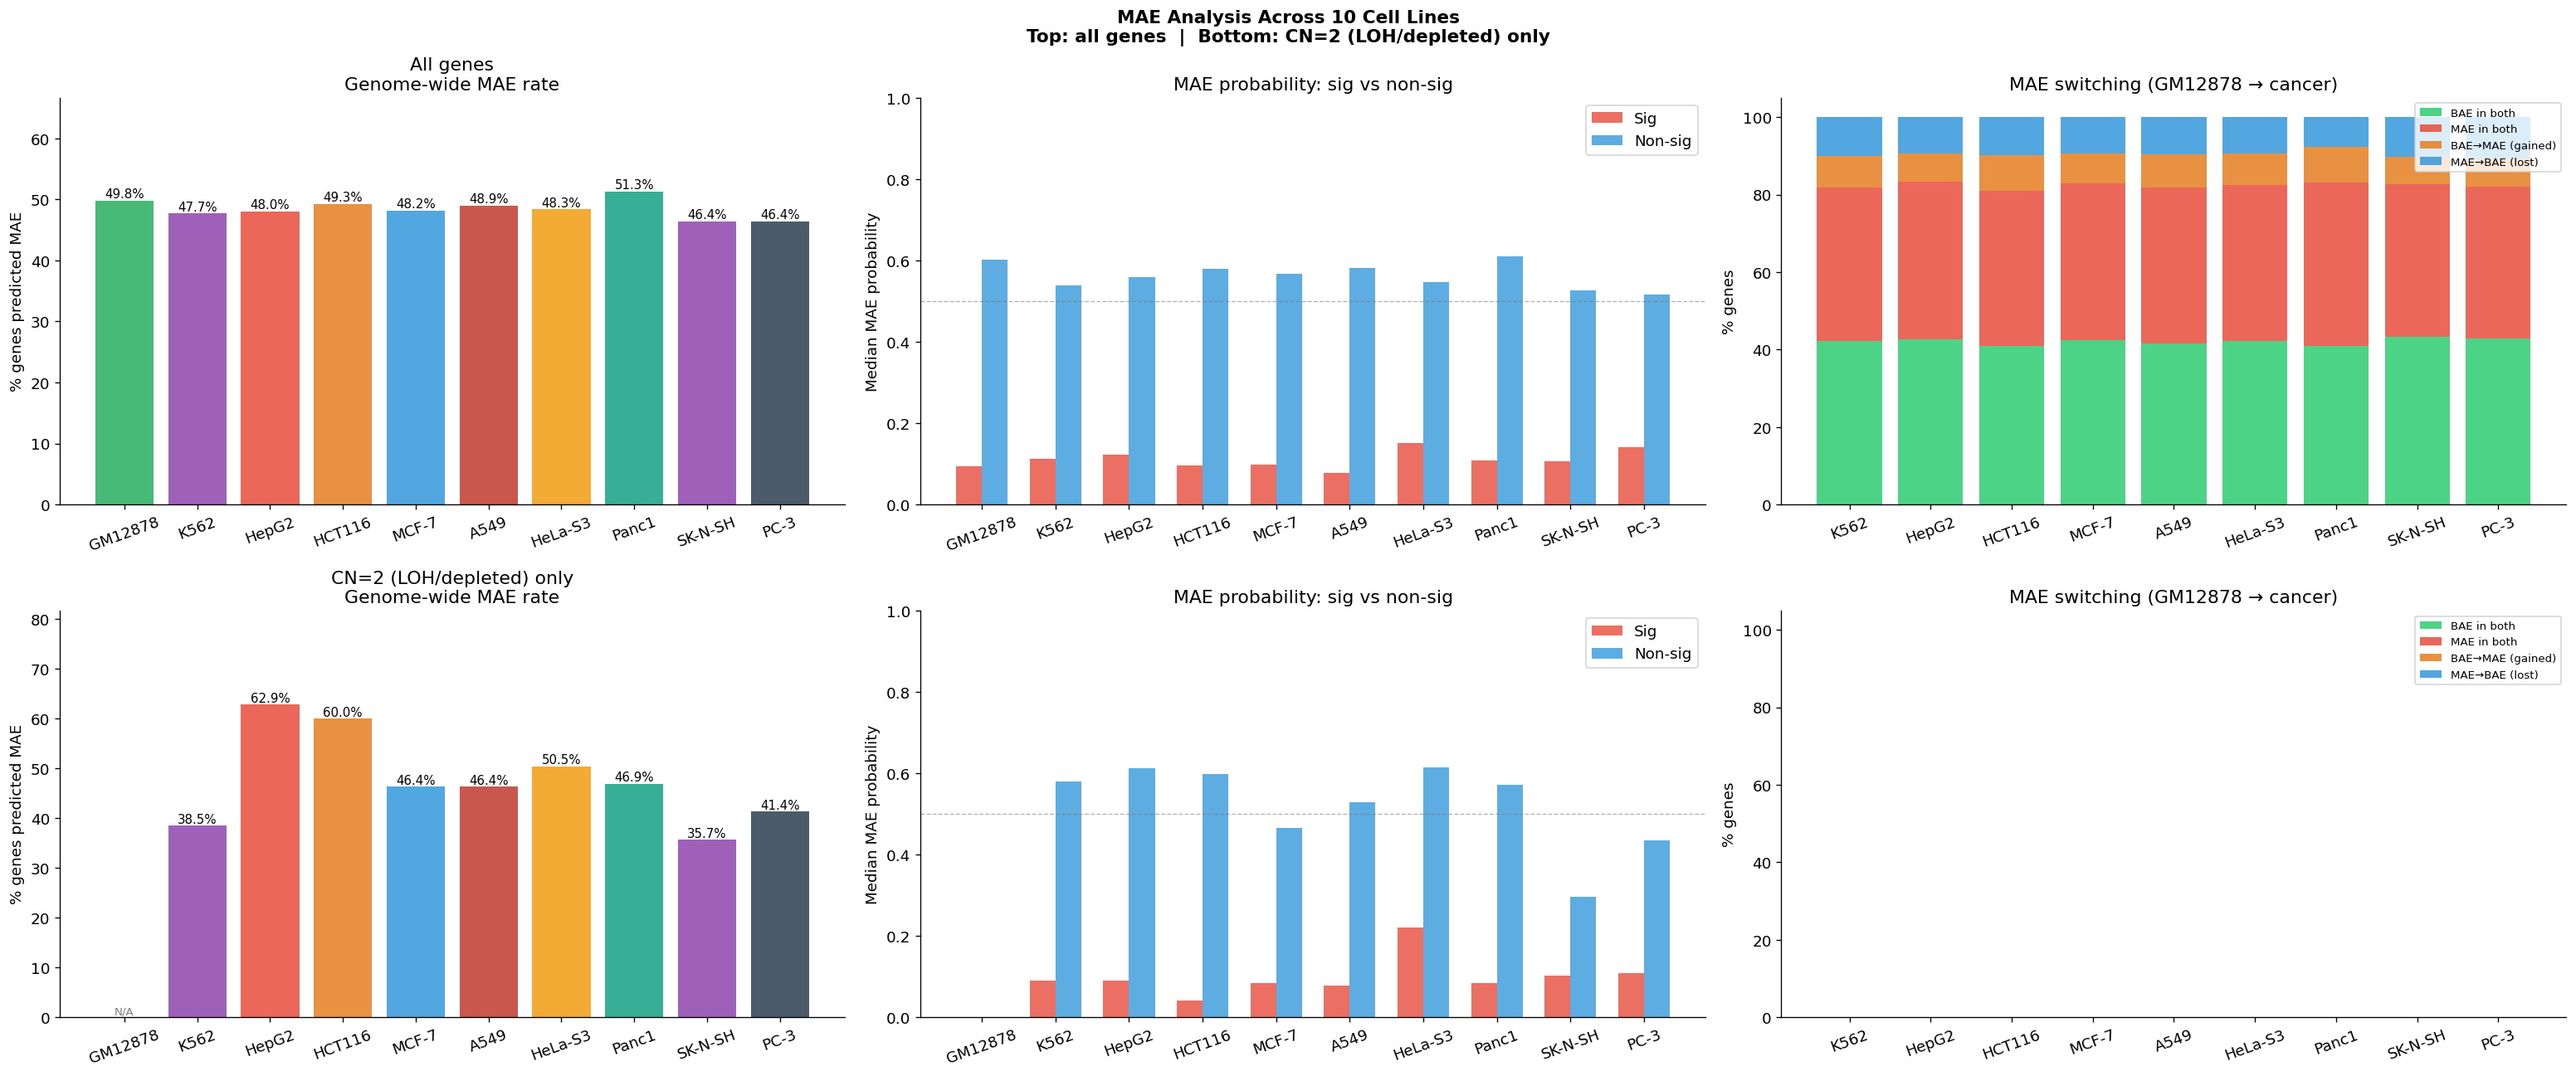

Figure saved: cancer_mae_analysis.png


In [25]:
# ── Visualisation: MAE across 5 cell lines (all genes + CN=2) ────────────────
cell_line_order = list(ENCODE_FILES.keys())
n_cl = len(cell_line_order)

CELL_COLORS = {
    'GM12878': '#27AE60',
    'K562':    '#8E44AD',
    'HepG2':   '#E74C3C',
    'HCT116':  '#E67E22',
    'MCF-7':   '#3498DB',
    'A549':    '#C0392B',
    'HeLa-S3': '#F39C12',
    'Panc1':   '#16A085',
    'SK-N-SH': '#8E44AD',
    'PC-3':    '#2C3E50',
}

fig, axes = plt.subplots(2, 3, figsize=(26, 11))
fig.suptitle('MAE Analysis Across 10 Cell Lines\nTop: all genes  |  Bottom: CN=2 (LOH/depleted) only',
             fontsize=13, fontweight='bold')

def plot_mae_row(axes_row, cn_filter, row_label):
    if cn_filter == 'all':
        sub_long = mae_long
    else:
        sub_long = mae_long[mae_long['cn_category'] == cn_filter]

    has_data = len(sub_long) > 0

    # Panel 1: genome-wide MAE rate
    ax = axes_row[0]
    rates = [sub_long[sub_long['cell_line'] == cl]['mae_pred'].mean() * 100
             for cl in cell_line_order]
    bars = ax.bar(cell_line_order, [r if not (isinstance(r, float) and np.isnan(r)) else 0 for r in rates],
                  color=[CELL_COLORS[cl] for cl in cell_line_order], alpha=0.85)
    ax.set_ylabel('% genes predicted MAE')
    ax.set_title(f'{row_label}\nGenome-wide MAE rate')
    valid_rates = [r for r in rates if not (isinstance(r, float) and np.isnan(r))]
    ax.set_ylim(0, max(valid_rates) * 1.3 if valid_rates else 100)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, rates):
        if not (isinstance(val, float) and np.isnan(val)):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                    f'{val:.1f}%', ha='center', fontsize=9)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, 0.5,
                    'N/A', ha='center', fontsize=8, color='grey')

    # Panel 2: median MAE probability sig vs non-sig
    ax = axes_row[1]
    x = np.arange(n_cl)
    width = 0.35
    sig_meds  = [np.median(sub_long[(sub_long['cell_line'] == cl) &  sub_long['is_sig']]['mae_prob'])
                 if (sub_long[(sub_long['cell_line'] == cl) & sub_long['is_sig']]).shape[0] > 0 else np.nan
                 for cl in cell_line_order]
    nsig_meds = [np.median(sub_long[(sub_long['cell_line'] == cl) & sub_long['is_nsig']]['mae_prob'])
                 if (sub_long[(sub_long['cell_line'] == cl) & sub_long['is_nsig']]).shape[0] > 0 else np.nan
                 for cl in cell_line_order]
    ax.bar(x - width/2, [v if not (isinstance(v, float) and np.isnan(v)) else 0 for v in sig_meds],
           width, label='Sig', color=SIG_COLOR, alpha=0.8)
    ax.bar(x + width/2, [v if not (isinstance(v, float) and np.isnan(v)) else 0 for v in nsig_meds],
           width, label='Non-sig', color=NSIG_COLOR, alpha=0.8)
    ax.set_ylabel('Median MAE probability')
    ax.set_title('MAE probability: sig vs non-sig')
    ax.set_xticks(x); ax.set_xticklabels(cell_line_order, rotation=20)
    ax.set_ylim(0, 1); ax.axhline(0.5, color='grey', linestyle='--', lw=0.8, alpha=0.6)
    ax.legend()

    # Panel 3: switching stacked bar (cancer lines vs GM12878)
    ax = axes_row[2]
    switch_cats = ['BAE in both', 'MAE in both', 'BAE→MAE (gained)', 'MAE→BAE (lost)']
    switch_colors_map = {
        'BAE in both': '#2ECC71', 'MAE in both': '#E74C3C',
        'BAE→MAE (gained)': '#E67E22', 'MAE→BAE (lost)': '#3498DB',
    }
    x2 = np.arange(len(CANCER_LINES))
    bottom = np.zeros(len(CANCER_LINES))
    for cat in switch_cats:
        vals = []
        for cl in CANCER_LINES:
            comp = comparisons[cl].copy()
            if cn_filter == 'CN=2':
                cn_cl  = cell_line_scores[cl].set_index('gene')['cn_category']
                cn_gm_ = cell_line_scores[BASELINE].set_index('gene')['cn_category']
                keep = [cn_cl.get(g,'unknown') == 'CN=2' and cn_gm_.get(g,'unknown') == 'CN=2'
                        for g in comp['gene']]
                comp = comp[keep]
            total = len(comp)
            vals.append((comp['switch'] == cat).sum() / total * 100 if total > 0 else 0)
        ax.bar(x2, vals, bottom=bottom, label=cat, color=switch_colors_map[cat], alpha=0.85)
        bottom += np.array(vals)
    ax.set_ylabel('% genes')
    ax.set_title('MAE switching (GM12878 → cancer)')
    ax.set_xticks(x2); ax.set_xticklabels(CANCER_LINES, rotation=20)
    ax.set_ylim(0, 105); ax.legend(loc='upper right', fontsize=8)

plot_mae_row(axes[0], 'all',  'All genes')
plot_mae_row(axes[1], 'CN=2', 'CN=2 (LOH/depleted) only')

plt.tight_layout()
plt.savefig('cancer_mae_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: cancer_mae_analysis.png')


## 12 · Summary Table — All Statistical Tests

In [26]:
# Compile all results with FDR correction
summary = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('U statistic',)}
    for r in all_results
])

summary['q-value (BH)'] = fdr_bh(summary['p-value'].tolist())

# Format
summary['Sig median']     = summary['Sig median'].round(3)
summary['Non-sig median'] = summary['Non-sig median'].round(3)
summary['p-value']        = summary['p-value'].apply(lambda x: f'{x:.4g}')
summary['q-value (BH)']   = summary['q-value (BH)'].apply(lambda x: f'{x:.4g}')

summary = summary[['Metric', 'Sig n', 'Sig median', 'Non-sig n', 'Non-sig median', 'p-value', 'q-value (BH)']]
print(summary.to_string(index=False))

summary.to_csv('statistical_summary.csv', index=False)
print('\nSummary saved: statistical_summary.csv')

                                        Metric  Sig n  Sig median  Non-sig n  Non-sig median   p-value q-value (BH)
                   RNA HL | Within-pair |diff|     26       2.786       7904           2.379    0.8332       0.9165
                         RNA HL | Pair mean HL     26       7.488       7904           5.207  0.005368      0.01968
                          RNA HL | Per-gene HL     52       7.319      15808           4.000 0.0001225     0.000674
               Protein HL | Within-pair |diff|     23      40.063       3970          49.552    0.4947       0.7774
                     Protein HL | Pair mean HL     23     105.725       3970         100.931    0.7224       0.8829
                      Protein HL | Per-gene HL     46     110.164       7940          91.598    0.3354       0.6149
           MAE [All genes] | Per-gene MAE prob     68       0.060      47196           0.751 7.043e-19    7.747e-18
    MAE | Pair concordance (both same MAE/BAE)     34       1.000      2

In [27]:
# ── Full compartment results saved ────────────────────────────────────────────
comp_df.to_csv('localisation_compartment_results.csv', index=False)
print('Compartment-level results saved: localisation_compartment_results.csv')

Compartment-level results saved: localisation_compartment_results.csv


## 13 · Combined Summary Figure

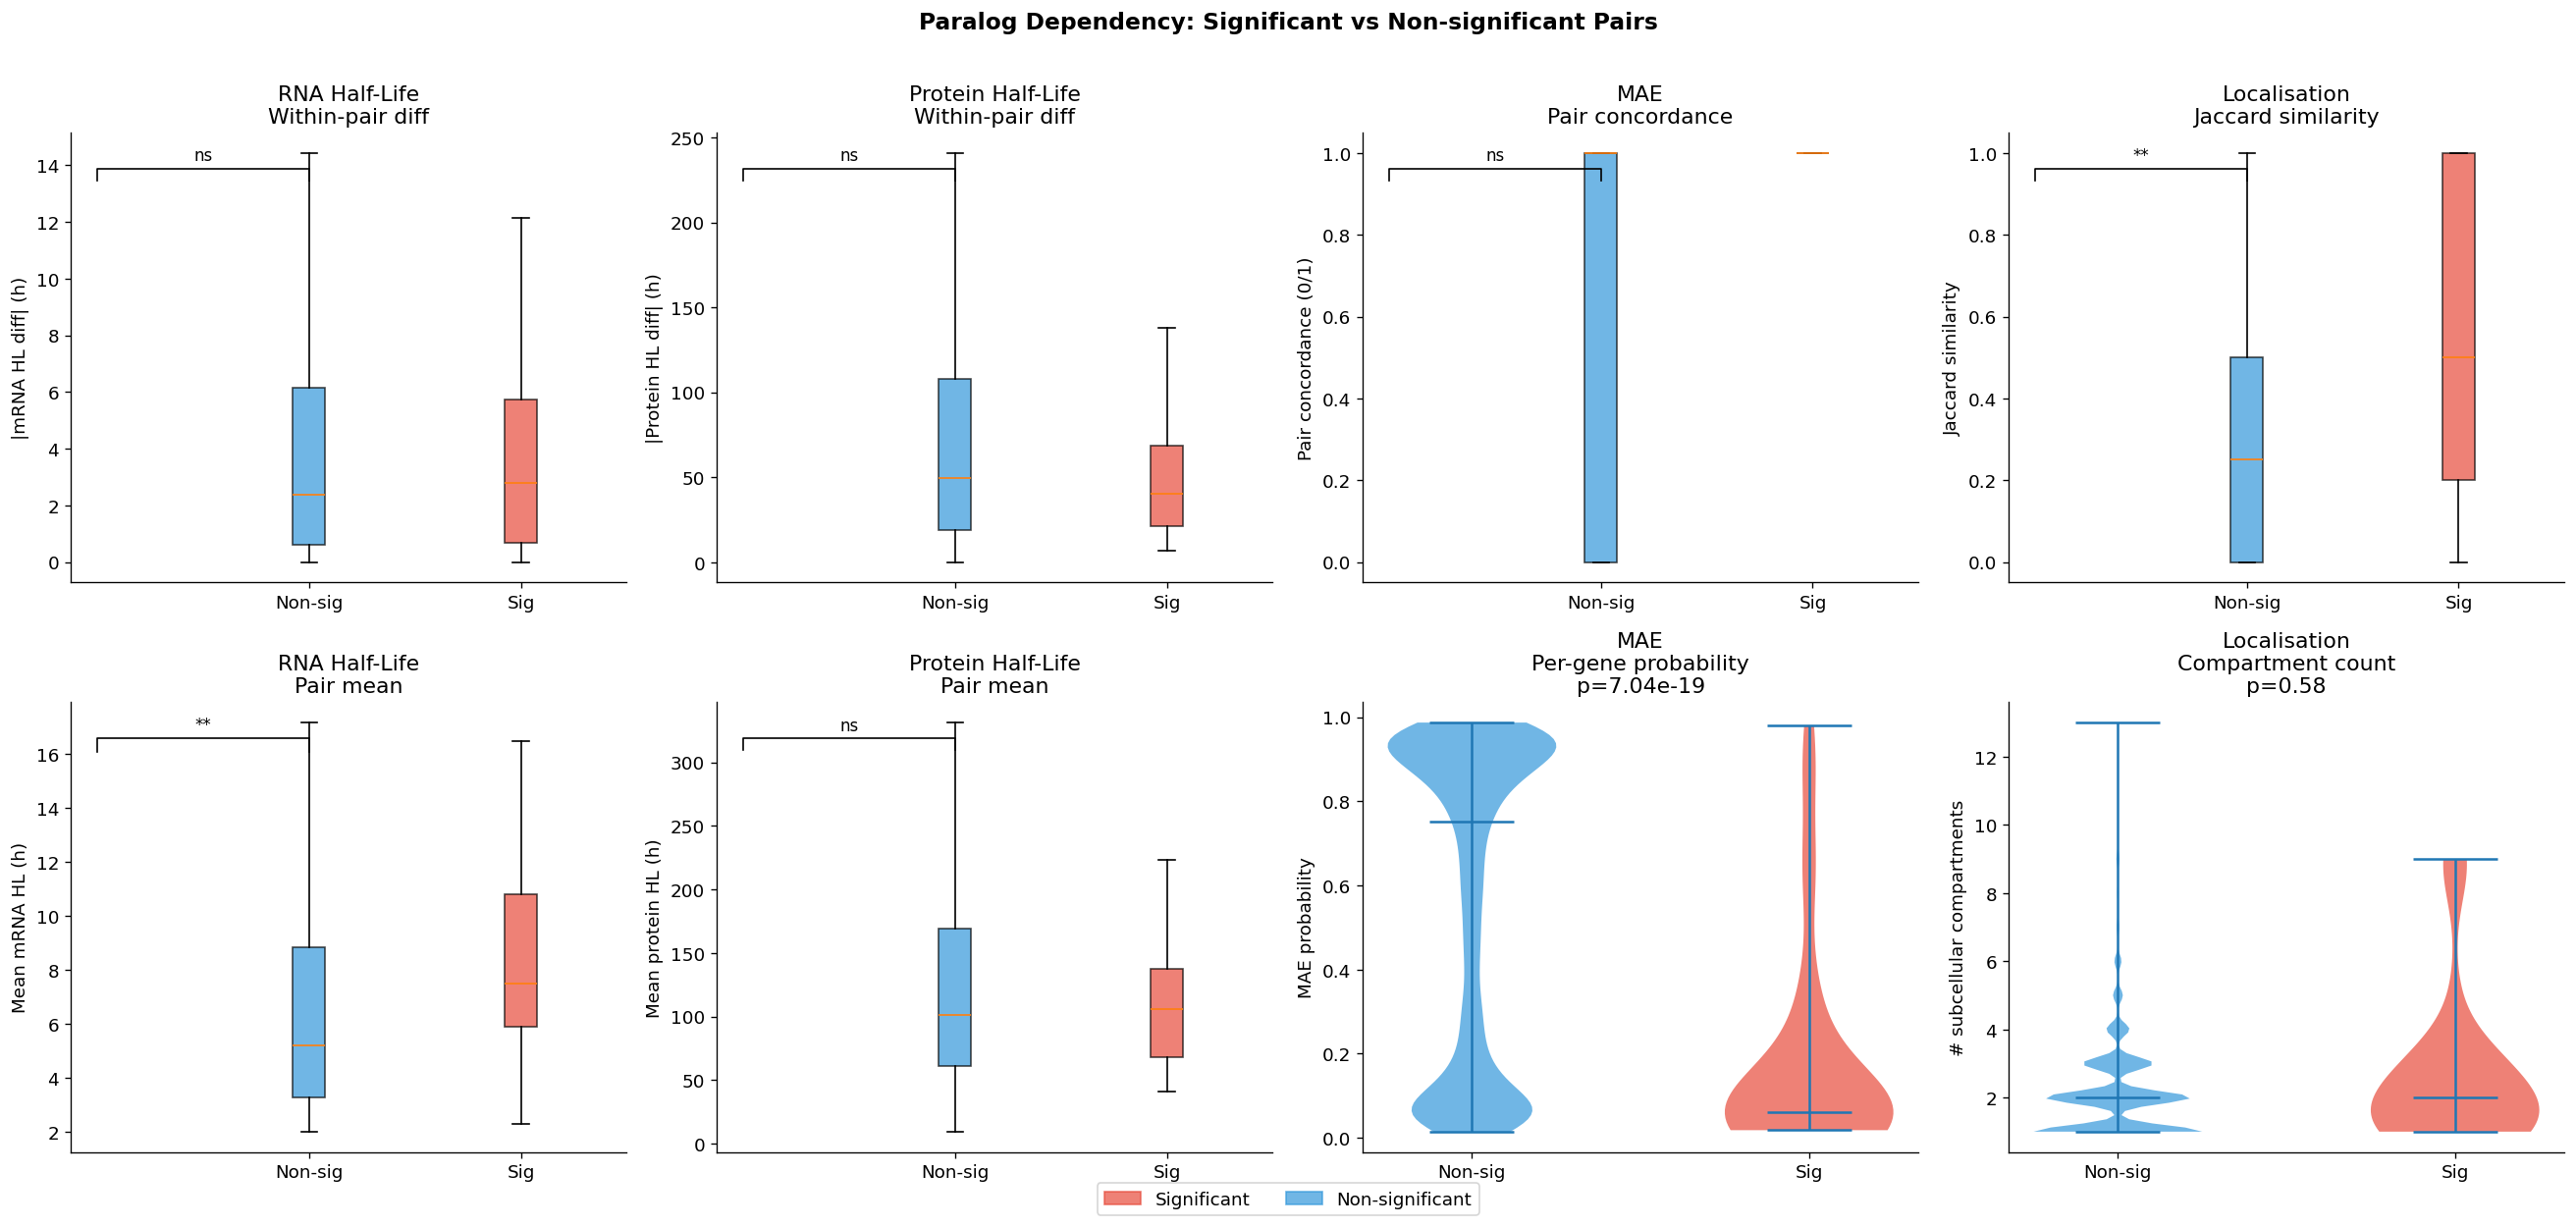

Combined figure saved: combined_summary_figure.png


In [28]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Paralog Dependency: Significant vs Non-significant Pairs', fontsize=14, fontweight='bold', y=1.01)

def add_pval(ax, p, pos1=0, pos2=1, y_offset=0.92):
    if p < 0.001: sig = '***'
    elif p < 0.01: sig = '**'
    elif p < 0.05: sig = '*'
    else: sig = 'ns'
    ylim = ax.get_ylim()
    y = ylim[0] + (ylim[1] - ylim[0]) * y_offset
    ax.plot([pos1, pos1, pos2, pos2], [y*0.97, y, y, y*0.97], lw=1, color='black')
    ax.text((pos1 + pos2) / 2, y * 1.01, sig, ha='center', va='bottom', fontsize=10)

# Helper: boxplot
def make_boxplot(ax, sig_vals, nsig_vals, ylabel, title, pval):
    bp = ax.boxplot([nsig_vals, sig_vals], labels=['Non-sig', 'Sig'], patch_artist=True, showfliers=False)
    for patch, color in zip(bp['boxes'], [NSIG_COLOR, SIG_COLOR]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    add_pval(ax, pval)

# Row 0: within-pair differences
make_boxplot(axes[0, 0], rhl_sig['hl_diff'].values, rhl_nsig['hl_diff'].values,
             '|mRNA HL diff| (h)', 'RNA Half-Life\nWithin-pair diff', float(r1['p-value']))
make_boxplot(axes[0, 1], phl_sig['hl_diff'].values, phl_nsig['hl_diff'].values,
             '|Protein HL diff| (h)', 'Protein Half-Life\nWithin-pair diff', float(r4['p-value']))
make_boxplot(axes[0, 2], mae_sig['concordant'].values.astype(float), mae_nsig['concordant'].values.astype(float),
             'Pair concordance (0/1)', 'MAE\nPair concordance', float(r8['p-value']))
make_boxplot(axes[0, 3], loc_sig['jaccard'].values, loc_nsig['jaccard'].values,
             'Jaccard similarity', 'Localisation\nJaccard similarity', float(r9['p-value']))

# Row 1: per-gene / mean metrics
make_boxplot(axes[1, 0], rhl_sig['hl_mean'].values, rhl_nsig['hl_mean'].values,
             'Mean mRNA HL (h)', 'RNA Half-Life\nPair mean', float(r2['p-value']))
make_boxplot(axes[1, 1], phl_sig['hl_mean'].values, phl_nsig['hl_mean'].values,
             'Mean protein HL (h)', 'Protein Half-Life\nPair mean', float(r5['p-value']))

# MAE probability violin
ax = axes[1, 2]
sig_probs_plot  = np.concatenate([mae_sig['prob_A'].values,  mae_sig['prob_B'].values])
nsig_probs_plot = np.concatenate([mae_nsig['prob_A'].values, mae_nsig['prob_B'].values])
parts = ax.violinplot([nsig_probs_plot, sig_probs_plot], positions=[0, 1], showmedians=True)
for pc, color in zip(parts['bodies'], [NSIG_COLOR, SIG_COLOR]):
    pc.set_facecolor(color); pc.set_alpha(0.7)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Non-sig', 'Sig'])
ax.set_ylabel('MAE probability')
ax.set_title(f'MAE\nPer-gene probability\np={float(r7["p-value"]):.3g}')

# Compartment count violin
ax = axes[1, 3]
sig_nlocs_plot  = np.concatenate([loc_sig['n_locs_A'].values,  loc_sig['n_locs_B'].values])
nsig_nlocs_plot = np.concatenate([loc_nsig['n_locs_A'].values, loc_nsig['n_locs_B'].values])
parts = ax.violinplot([nsig_nlocs_plot, sig_nlocs_plot], positions=[0, 1], showmedians=True)
for pc, color in zip(parts['bodies'], [NSIG_COLOR, SIG_COLOR]):
    pc.set_facecolor(color); pc.set_alpha(0.7)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Non-sig', 'Sig'])
ax.set_ylabel('# subcellular compartments')
ax.set_title(f'Localisation\nCompartment count\np={float(r10["p-value"]):.3g}')

# Legend
sig_patch  = mpatches.Patch(color=SIG_COLOR,  alpha=0.7, label='Significant')
nsig_patch = mpatches.Patch(color=NSIG_COLOR, alpha=0.7, label='Non-significant')
fig.legend(handles=[sig_patch, nsig_patch], loc='lower center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('combined_summary_figure.png', dpi=150, bbox_inches='tight')
plt.show()
print('Combined figure saved: combined_summary_figure.png')

## 14 · Data Coverage Report

In [ ]:
coverage = pd.DataFrame([
    {'Analysis': 'RNA half-life',        'Dataset': 'Tani 2012 (human)',
     'Sig pairs': len(rhl_sig), 'Non-sig pairs': len(rhl_nsig)},
    {'Analysis': 'Protein half-life',    'Dataset': 'Mathieson 2018 (human, 4 cell types)',
     'Sig pairs': len(phl_sig), 'Non-sig pairs': len(phl_nsig)},
    {'Analysis': 'MAE',                  'Dataset': 'MaGIC/Nag 2013 classifier (10 ENCODE cell lines)',
     'Sig pairs': len(mae_sig), 'Non-sig pairs': len(mae_nsig)},
    {'Analysis': 'Protein localisation', 'Dataset': 'Human Protein Atlas v25',
     'Sig pairs': len(loc_sig), 'Non-sig pairs': len(loc_nsig)},
])

coverage['Sig coverage'] = (coverage['Sig pairs'] / len(sig_pairs) * 100).round(1).astype(str) + '%'
coverage['Non-sig coverage'] = (coverage['Non-sig pairs'] / len(ns_pairs) * 100).round(1).astype(str) + '%'

print('Data coverage per analysis:')
print(coverage.to_string(index=False))